<a href="https://colab.research.google.com/github/Erjg1012/Procesamiento-de-Lenguaje-Natural-PLN-/blob/main/Monitoreo_de_tendencias_en_atenci%C3%B3n_m%C3%A9dica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 4. Monitoreo de tendencias en atención médica (extracción de semántica y clasificación de diagnósticos)

## Objetivo:
Desarrollar un sistema que, a partir de un conjunto de datos médicos (por ejemplo, reportes clínicos, registros de hospital, descripciones
de síntomas, etc.), extraiga información clave (entidades como enfermedades, fármacos, síntomas, etc.) y clasifique el tipo de diagnóstico o la
urgencia de cada caso (leve, moderado, crítico). Adicionalmente, el sistema debe monitorear tendencias en la atención médica, como la frecuencia
de determinados diagnósticos o patrones de síntomas a lo largo del tiempo.

## Introducción:

El análisis de textos clínicos es fundamental para mejorar la comprensión y gestión de la información médica. La gran cantidad de datos no estructurados presentes en notas médicas requiere el uso de técnicas avanzadas de procesamiento de lenguaje natural para extraer información valiosa. Este tipo de análisis permite identificar patrones en síntomas, diagnósticos y tratamientos, contribuyendo a mejorar la atención y el seguimiento de los pacientes.

## Importación de Librerias

In [ ]:
!pip install -U spacy
!python -m spacy download es_core_news_sm
# Add a command to link the downloaded model if the download succeeds
!python -m spacy link es_core_news_sm es_core_news_sm --force
!pip install transformers
!pip install -U transformers
!pip install sentence-transformers
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 transformers==4.31.0 sentence-transformers
!apt-get install -y graphviz
!pip install graphviz pydotplus
# Remove the final uninstall command that removes transformers
# !pip uninstall -y torch torchvision torchaudio transformers
!pip uninstall -y torch torchvision torchaudio transformers
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 --index-url https://download.pytorch.org/whl/cpu
!pip install transformers==4.31.0
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 2.2.2 requires torch>=1.6.0, which is not installed.
sentence-transformers 2.2.2 requires torchvision, which is not installed.
fastai 2.7.19 requires torch<2.7,>=1.10, which is not installed.
fastai 2.7.19 requires torchvision>=0.11, which is not installed.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
pyfume 0.3.4 requires numpy==1.24.4, but you have numpy 2.2.6 which is incompatible.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.2.6 which is incompa

In [ ]:
# Desinstalar todo lo relacionado a torch y transformers
!pip uninstall -y torch torchvision torchaudio transformers

# Instalar versiones estables sin triton_ops
!pip install torch==1.13.1 torchvision==0.14.1 torchaudio==0.13.1 --index-url https://download.pytorch.org/whl/cpu

# Instalar Transformers compatible
!pip install transformers==4.26.1

Found existing installation: transformers 4.26.1
Uninstalling transformers-4.26.1:
  Successfully uninstalled transformers-4.26.1
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-1.13.1%2Bcpu-cp311-cp311-linux_x86_64.whl (199.1 MB)
ERROR: Could not find a version that satisfies the requirement torchvision==0.14.1 (from versions: 0.1.6, 0.2.0, 0.15.0+cpu, 0.15.1+cpu, 0.15.2+cpu, 0.16.0+cpu, 0.16.1+cpu, 0.16.2+cpu, 0.17.0+cpu, 0.17.1+cpu, 0.17.2+cpu, 0.18.0+cpu, 0.18.1+cpu, 0.19.0+cpu, 0.19.1+cpu, 0.20.0+cpu, 0.20.1+cpu, 0.21.0+cpu, 0.22.0+cpu)
ERROR: No matching distribution found for torchvision==0.14.1
  Using cached transformers-4.26.1-py3-none-any.whl.metadata (100 kB)
Using cached transformers-4.26.1-py3-none-any.whl (6.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transforme

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.24.4


Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 2.2.2 requires torch>=1.6.0, which is not installed.
sentence-transformers 2.2.2 requires torchvision, which is not installed.
fastai 2.7.19 requires torch<2.7,>=1.10, which is not installed.
fastai 2.7.19 requires torchvision>=0.11, which is not installed.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
cvxpy 1.6.5 requires scipy>=1.11.0, but you have scipy 1.10.1 which is incompati

In [ ]:
import pandas as pd
import spacy
import re
from spacy.lang.es.stop_words import STOP_WORDS
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import pydotplus
from IPython.display import Image
import graphviz
from collections import Counter
import seaborn as sns
from itertools import combinations
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score

## 1. Recolección de datos:


### a) Usar datasets públicos de notas clínicas o textos médicos anonimizados (MIMIC-III, datasets de síntomas, enfermedades o urgencias).

In [ ]:
df = pd.read_excel("meddocan_train.xlsx")

In [ ]:
df.head(5)

,archivo,texto,entidades
0,S1139-13752006000200009-1,Datos del paciente. Nombre: Ignacio. Apellido...,CORREO_ELECTRONICO: pico_lui@gva.es; TERRITORI...
1,S0210-56912009000600008-1,Nombre: David. Apellidos: Herrera Andrade. NH...,ID_ASEGURAMIENTO: 78 45412245 45; CORREO_ELECT...
2,S1137-66272009000500015-1,Datos del paciente. Nombre: Marcial. Apellido...,CORREO_ELECTRONICO: lekimrico@hotmail.com; NUM...
3,S1137-66272014000300015-1,Datos del paciente. Nombre: Juana. Apellidos: ...,CORREO_ELECTRONICO: aida.rico.arrastia@cfnavar...
4,S0376-78922014000200012-1,Nombre: Luis Miguel. Apellidos: Gonzalez Duva...,"TERRITORIO: Ciudad de México, Distrito Federal..."


Esta muestra inicial del DataFrame revela que los datos provienen de documentos clínicos estructurados con información personal anonimizada y metadatos importantes como nombre, apellidos, y entidades clínicas reconocidas automáticamente (como correos electrónicos, números de aseguramiento, territorio, etc.).

Esta organización es adecuada para realizar análisis semánticos y extracción de entidades médicas, permitiendo enlazar texto con datos estructurados para posteriores procesos de limpieza, clasificación y análisis.

La inclusión de múltiples campos de texto enriquecido y entidades detectadas favorece la creación de modelos de monitoreo y clasificación basados en características clínicas reales y contextuales.

### b) Verificar campos como la descripción clínica, diagnostico si el dataset esta etiquetado y posiblemente la fecha para tendencias.

In [ ]:
def limpiar_texto(texto):
    texto = texto.replace("\n", " ")
    texto = re.sub(r"\s+", " ", texto)
    return texto.lower().strip()

df["texto_limpio"] = df["texto"].apply(limpiar_texto)

In [ ]:
# Funciones para extracción
def extraer_nombre(texto): return re.search(r"Nombre:\s*([A-ZÁÉÍÓÚÑ][a-záéíóúñ]+)", texto).group(1) if re.search(r"Nombre:\s*([A-ZÁÉÍÓÚÑ][a-záéíóúñ]+)", texto) else None
def extraer_apellidos(texto): return re.search(r"Apellidos?:\s*([\w\sÁÉÍÓÚÑáéíóúñ]+)", texto).group(1) if re.search(r"Apellidos?:\s*([\w\sÁÉÍÓÚÑáéíóúñ]+)", texto) else None
def extraer_nhc(texto): return re.search(r"NHC:\s*(\d+)", texto).group(1) if re.search(r"NHC:\s*(\d+)", texto) else None
def extraer_nass(texto): return re.search(r"NASS:\s*([\d\s]+)", texto).group(1).strip() if re.search(r"NASS:\s*([\d\s]+)", texto) else None
def extraer_correo(texto): return re.search(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", texto).group(0) if re.search(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", texto) else None
def extraer_domicilio(texto): return re.search(r"Domicilio:\s*(.*?)(?:\.|Localidad|CP:|$)", texto).group(1).strip() if re.search(r"Domicilio:\s*(.*?)(?:\.|Localidad|CP:|$)", texto) else None
def extraer_cp(texto): return re.search(r"CP:\s*(\d{5})", texto).group(1) if re.search(r"CP:\s*(\d{5})", texto) else None
def extraer_localidad(texto): return re.search(r"Localidad/ Provincia:\s*(.*?)(?:\.|CP:|$)", texto).group(1).strip() if re.search(r"Localidad/ Provincia:\s*(.*?)(?:\.|CP:|$)", texto) else None
def extraer_edad(texto): return re.search(r"Edad:\s*(\d+)", texto).group(1) if re.search(r"Edad:\s*(\d+)", texto) else None
def extraer_sexo(texto): return re.search(r"Sexo:\s*([HM])", texto).group(1) if re.search(r"Sexo:\s*([HM])", texto) else None
def extraer_fecha_nacimiento(texto): return re.search(r"Fecha de nacimiento:\s*(\d{2}/\d{2}/\d{4})", texto).group(1) if re.search(r"Fecha de nacimiento:\s*(\d{2}/\d{2}/\d{4})", texto) else None
def extraer_fecha_ingreso(texto): return re.search(r"Fecha de Ingreso:\s*(\d{2}/\d{2}/\d{4})", texto).group(1) if re.search(r"Fecha de Ingreso:\s*(\d{2}/\d{2}/\d{4})", texto) else None
def extraer_pais(texto): return re.search(r"Pa[ií]s:\s*([A-Za-zÁÉÍÓÚáéíóúñÑ ]+)", texto).group(1).strip() if re.search(r"Pa[ií]s:\s*([A-Za-zÁÉÍÓÚáéíóúñÑ ]+)", texto) else None
def extraer_medico(texto): return re.search(r"M[eé]dico:\s*([\w\sÁÉÍÓÚáéíóúñÑ]+)", texto).group(1).strip() if re.search(r"M[eé]dico:\s*([\w\sÁÉÍÓÚáéíóúñÑ]+)", texto) else None
def extraer_num_colegiado(texto): return re.search(r"N[º°]Col:\s*([\d\s]+)", texto).group(1).strip() if re.search(r"N[º°]Col:\s*([\d\s]+)", texto) else None

sintomas_ext = [
    "disnea", "fiebre", "tos", "estridor", "taquipnea", "ortopnea", "drenajes", "dolor torácico",
    "mareo", "náuseas", "vómito", "cefalea", "astenia", "dolor", "cansancio", "palpitaciones",
    "hipotensión", "hipertensión", "fatiga", "hemoptisis", "sudoración", "prurito", "anorexia",
    "edema", "escalofríos", "pérdida de peso", "pérdida de apetito", "insomnio", "somnolencia",
    "debilidad", "temblor", "dolor abdominal", "urgencia urinaria", "incontinencia", "confusión",
    "disfagia", "disfonía", "rinitis", "mialgia", "artralgia", "dolor lumbar", "alergia", "visión borrosa",
    "sangrado", "dolor pélvico", "dolor ocular", "entumecimiento", "visión doble", "palidez", "hinchazón",
    "zumbido", "pirosis", "reflujo", "diarrea", "estreñimiento", "deshidratación", "desmayo",
    "inestabilidad", "irritabilidad", "ansiedad", "depresión", "alucinaciones", "convulsiones",
    "bradicardia", "taquicardia", "aturdimiento", "opresión", "estornudos", "hormigueo", "molestias",
    "lagrimeo", "asintomático", "hiperglucemia", "enrojecimiento", "hipertermia", "hipoglucemia", "diplopía",
    "xerostomía", "poliuria", "polidipsia", "parestesia", "claudicación", "cianosis", "ictericia"
]



medicamentos_ext = [
    "amoxicilina", "glucosa", "oxígeno", "heparina", "morfina", "vancomicina", "clindamicina",
    "meropenem", "furosemida", "enalapril", "paracetamol", "ibuprofeno", "metformina", "insulina",
    "azitromicina", "omeprazol", "losartán", "salbutamol", "levotiroxina", "prednisona",
    "simvastatina", "atorvastatina", "ceftriaxona", "hidrocortisona", "lorazepam", "alprazolam",
    "amiodarona", "amoxiclav", "diclofenaco", "ketorolaco", "hidroxicloroquina", "gabapentina",
    "tramadol", "clopidogrel", "acenocumarol", "warfarina", "nifedipino", "ranitidina", "famotidina",
    "pantoprazol", "dexametasona", "metadona", "carbamazepina", "haloperidol", "sertralina",
    "fluoxetina", "venlafaxina", "lamotrigina", "lidocaína", "buscapina", "loratadina", "desloratadina",
    "rifampicina", "isoniacida", "etanercept", "adalimumab", "infliximab", "budesonida", "riluzol",
    "bevacizumab", "rituximab", "anastrozol", "capecitabina", "everolimus", "sunitinib", "nivolumab",
    "pembrolizumab", "tamsulosina", "amlodipino", "clozapina", "rosuvastatina", "linagliptina", "dapagliflozina",
    "pioglitazona", "canagliflozina"
]



enfermedades_ext = [
    "hidrotórax", "nefroangioesclerosis", "insuficiencia renal crónica", "estenosis traqueal",
    "hipercolesterolemia", "cardiopatía isquémica", "enfermedad coronaria aguda", "diabetes",
    "hipertensión", "asma", "epoc", "anemia", "artritis", "trombosis", "ictus", "leucemia",
    "neumonía", "fibrosis pulmonar", "hepatitis", "esclerosis múltiple", "lupus", "insuficiencia cardíaca",
    "infarto agudo de miocardio", "gastritis", "úlcera péptica", "cirrosis", "alzheimer", "parkinson",
    "esquizofrenia", "depresión", "hipotiroidismo", "hipertiroidismo", "síndrome nefrótico",
    "cáncer de pulmón", "cáncer de colon", "cáncer de mama", "covid", "sida", "hiv", "obesidad",
    "estenosis aórtica", "estenosis mitral", "miocardiopatía", "endocarditis", "pancreatitis",
    "bronquitis", "sinusitis", "otitis", "dermatitis", "celulitis", "apendicitis", "neoplasia",
    "tuberculosis", "melanoma", "glioblastoma", "linfoma", "mieloma", "colitis", "poliartritis",
    "metástasis", "carcinoma", "psoriasis", "celiaquía", "miastenia gravis", "síndrome de cushing",
    "enfermedad de crohn", "síndrome metabólico", "espondilitis anquilosante"
]



procedimientos_ext = [
    "diálisis", "radiografía", "toracocentesis", "ecocardiografía", "broncoscopia", "pleurodesis",
    "catéter", "biopsia", "quimioterapia", "resección", "intubación", "extubación", "cirugía",
    "ventilación mecánica", "fibrobroncoscopia", "angioplastia", "hemodiálisis", "transfusión",
    "endoscopia", "colonoscopia", "laparoscopia", "toracotomía", "traqueotomía", "electrocardiograma",
    "ecografía", "tac", "resonancia magnética", "cirugía laparoscópica", "toracoscopia", "marcapasos",
    "colocación de stent", "colocación de sonda", "infiltración", "cesárea", "resección tumoral",
    "litotricia", "intubación endotraqueal", "cirugía cardíaca", "amputación", "radioterapia",
    "lavado broncoalveolar", "biopsiado", "cateterización", "neurocirugía", "angiografía", "drenaje",
    "punción", "monitorización", "sedación", "aerosolterapia", "colangiografía", "toracocentesis diagnóstica",
    "gastroscopia", "artroscopia", "esplenectomía"
]

def extraer_lista(texto, lista):
    return list(set(re.findall(r"\b(" + "|".join(lista) + r")\b", texto, re.IGNORECASE))) if texto else None

# Aplicar sobre DataFrame
df["Nombre"] = df["texto"].apply(extraer_nombre)
df["Apellidos"] = df["texto"].apply(extraer_apellidos)
df["NHC"] = df["texto"].apply(extraer_nhc)
df["NASS"] = df["texto"].apply(extraer_nass)
df["Correo"] = df["texto"].apply(extraer_correo)
df["Domicilio"] = df["texto"].apply(extraer_domicilio)
df["CP"] = df["texto"].apply(extraer_cp)
df["Localidad"] = df["texto"].apply(extraer_localidad)
df["Edad"] = df["texto"].apply(extraer_edad)
df["Sexo"] = df["texto"].apply(extraer_sexo)
df["FechaNacimiento"] = df["texto"].apply(extraer_fecha_nacimiento)
df["FechaIngreso"] = df["texto"].apply(extraer_fecha_ingreso)
df["País"] = df["texto"].apply(extraer_pais)
df["Médico"] = df["texto"].apply(extraer_medico)
df["NumColegiado"] = df["texto"].apply(extraer_num_colegiado)
df["Síntomas"] = df["texto_limpio"].apply(lambda t: extraer_lista(t, sintomas_ext))
df["Medicamentos"] = df["texto_limpio"].apply(lambda t: extraer_lista(t, medicamentos_ext))
df["Enfermedades"] = df["texto_limpio"].apply(lambda t: extraer_lista(t, enfermedades_ext))
df["Procedimientos"] = df["texto_limpio"].apply(lambda t: extraer_lista(t, procedimientos_ext))

df

,archivo,texto,entidades,texto_limpio,Nombre,Apellidos,NHC,NASS,Correo,Domicilio,...,Sexo,FechaNacimiento,FechaIngreso,País,Médico,NumColegiado,Síntomas,Medicamentos,Enfermedades,Procedimientos
0,S1139-13752006000200009-1,Datos del paciente. Nombre: Ignacio. Apellido...,CORREO_ELECTRONICO: pico_lui@gva.es; TERRITORI...,datos del paciente. nombre: ignacio. apellidos...,Ignacio,Herrejon Valero,3495981,47 56358907 50,pico_lui@gva.es,"Avenida de la república, 19, 3 A",...,H,25/12/1952,21/09/2011,España,Luis Picó Vicent NºCol,03 03 20150,"[drenajes, disnea, ortopnea]",[glucosa],"[cardiopatía isquémica, nefroangioesclerosis, ...","[radiografía, toracocentesis, hemodiálisis, di..."
1,S0210-56912009000600008-1,Nombre: David. Apellidos: Herrera Andrade. NH...,ID_ASEGURAMIENTO: 78 45412245 45; CORREO_ELECT...,nombre: david. apellidos: herrera andrade. nhc...,David,Herrera Andrade,9865327,78 45412245 45,miguelangelfernandezvaquero@yahoo.es,"Calle Donante de Sangre, 19",...,H,12/09/1971,31/10/2016,España,Miguel Ángel Fernández Vaquero NºCol,02 19 45632,"[taquipnea, disnea, estridor]",[oxígeno],"[estenosis traqueal, enfermedad coronaria agud...","[broncoscopia, fibrobroncoscopia, ecocardiogra..."
2,S1137-66272009000500015-1,Datos del paciente. Nombre: Marcial. Apellido...,CORREO_ELECTRONICO: lekimrico@hotmail.com; NUM...,datos del paciente. nombre: marcial. apellidos...,Marcial,Allende Zamora,8342975,31 92740649 04,lekimrico@hotmail.com,"Paseo de Gracia, 34, 5A",...,H,25/11/1958,29/05/2014,España,Mikel Rico Osés NºCol,31 31 25601,"[asintomático, astenia, inestabilidad, sangrad...",[],"[carcinoma, metástasis]","[tac, biopsia, radioterapia, gastroscopia]"
3,S1137-66272014000300015-1,Datos del paciente. Nombre: Juana. Apellidos: ...,CORREO_ELECTRONICO: aida.rico.arrastia@cfnavar...,datos del paciente. nombre: juana. apellidos: ...,Juana,Martinez Ramos,4986734,32 75643095 06,aida.rico.arrastia@cfnavarra.es,"C/ Verona, 16, 1 D",...,M,24/06/1960,22/12/2017,España,Aida Rico Arrastia NºCol,31 31 52103,[],[],"[carcinoma, cáncer de mama, metástasis]","[cirugía, biopsia, drenaje, ecografía, quimiot..."
4,S0376-78922014000200012-1,Nombre: Luis Miguel. Apellidos: Gonzalez Duva...,"TERRITORIO: Ciudad de México, Distrito Federal...",nombre: luis miguel. apellidos: gonzalez duval...,Luis,Gonzalez Duval,07815635,None,fgg_9@hotmail.com,Ignacio L,...,H,27/12/1969,28/04/2018,México,Federico García García,None,"[dolor, edema]","[clindamicina, vancomicina, meropenem]",[celulitis],[cirugía]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,S0365-66912005001100010-2,Datos del paciente. Nombre: Pedro . Apellidos:...,CORREO_ELECTRONICO: janeiropais@canalejo.org; ...,datos del paciente. nombre: pedro . apellidos:...,Pedro,Iglesias Pastor,1149404,343551107164,janeiropais@canalejo.org,"Rúa Comandante Fontanes, 19, 2 B",...,H,09/05/1945,02/04/2013,None,José Manuel Janeiro Pais NºCol,15 15 65203,[],[],[],[]
496,S0004-06142006000500002-3,Datos del paciente. Nombre: Francisco. Apellid...,CORREO_ELECTRONICO: nachorutor@hotmail.com; PA...,datos del paciente. nombre: francisco. apellid...,Francisco,Prat Roque,2598763,None,nachorutor@hotmail.com,"Calle Moratalaz, 23, 1D",...,H,15/04/1983,06/06/2018,España,Ignacio Rubio Tortosa NºCol,28 28 27182,[],[],"[neoplasia, metástasis]","[tac, biopsia, infiltración, ecografía]"
497,S0004-06142006000900008-1,Nombre: Lidia . Apellidos: Castillo Vidal . CI...,CORREO_ELECTRONICO: manuelcabreracastillo@gmai...,nombre: lidia . apellidos: castillo vidal . ci...,Lidia,Castillo Vidal,915943,28 19237866 22,manuelcabreracastillo@gmail.com,"Calle villa de Marin 6, 12 F",...,M,None,None,España,urologia NºCol,28 28 15963,[hipertensión],[enalapril],"[hipotiroidismo, hipertensión]","[tac, ecografía, resección]"
498,S0004-06142006000200013-1,Datos del paciente. Nombre: Elena . Apellidos:...,CORREO_ELECTRONICO: javiertorresgomez@yahoo.es...,datos del paciente. nombre: elena . apellidos:...,Elena,Castillo Zamorano

En esta fase, realizamos la limpieza y estructuración del dataset inicial. Aplicamos un proceso sistemático para normalizar el texto clínico, eliminando caracteres especiales y unificando formatos para facilitar el análisis.

Luego, desarrollamos funciones específicas para extraer automáticamente campos relevantes de cada registro, tales como nombre, apellidos, número de historia clínica, correo electrónico, domicilio, sexo, fechas importantes y datos del médico responsable. Además, identificamos y categorizamos entidades clínicas clave —síntomas, medicamentos, enfermedades y procedimientos— transformándolas en listas estructuradas para cada documento.

Este trabajo conjunto nos permitió obtener un dataset limpio, organizado y enriquecido, que respeta el contexto clínico original y facilita la posterior exploración estadística y modelado. Gracias a esta base sólida, podremos avanzar con mayor precisión y eficiencia en el análisis de tendencias y patrones clínicos.

In [ ]:
# Extracción de campos útiles de diagnóstico o metadatos (ejemplo)
def extraer_fecha_ingreso(texto):
    return re.search(r"Fecha de Ingreso:\s*(\d{2}/\d{2}/\d{4})", texto).group(1) if re.search(r"Fecha de Ingreso:\s*(\d{2}/\d{2}/\d{4})", texto) else None

df["FechaIngreso"] = df["texto"].apply(extraer_fecha_ingreso)
df["FechaIngreso"]

,FechaIngreso
0,21/09/2011
1,31/10/2016
2,29/05/2014
3,22/12/2017
4,28/04/2018
...,...
495,02/04/2013
496,06/06/2018
497,None
498,03/09/2016


En esta etapa, nuestro equipo implementó la extracción de metadatos relevantes para el análisis, enfocándonos en campos clave como la fecha de ingreso del paciente. Desarrollamos una función específica que identifica y extrae automáticamente la fecha dentro del texto clínico, aplicando expresiones regulares para asegurar la correcta captura del formato.

Al aplicar esta función sobre nuestro dataset, logramos estructurar este campo en una columna separada y ordenada, facilitando la posterior agrupación y análisis temporal de los datos clínicos. Esta organización nos permite estudiar la evolución y tendencias de los diagnósticos a lo largo del tiempo con mayor precisión.

Luego de aplicar la función para extraer la fecha de ingreso de cada paciente desde los textos clínicos, obtuvimos una columna estructurada con estas fechas en formato día/mes/año. Esto nos permitió contar con un campo temporal que es clave para realizar análisis longitudinales y detectar tendencias a lo largo del tiempo en el conjunto de datos.

Notamos que algunas entradas no cuentan con esta información (valores None), por lo que es importante tener en cuenta estos casos para un correcto manejo de datos faltantes durante etapas posteriores del análisis.

En total, contamos con 500 registros con fechas, lo que nos brinda una base sólida para evaluar la distribución y evolución de los diagnósticos y tratamientos a lo largo de los años.

## 2. Limpieza, Tokenización y Normalización:

### a) Conversión del texto a minúsculas y normalización de caracteres especiales (tildes, eñes, etc.).

### b) Eliminación de stopwords. Usando librerías o listas de palabras vacías en el dominio medico.

### c) Tokenización y Lematización con diccionarios clínicos (Opcional)

In [ ]:
import spacy
nlp = spacy.load("es_core_news_sm")

In [ ]:
stopwords_clinicas = STOP_WORDS.union({
    "paciente", "presenta", "refiere", "consulta", "nombre", "fecha", "años",
    "sexo", "edad", "se", "ingresa", "realiza", "datos", "hospital", "informe"
})

def limpiartexto(texto):


    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñ0-9\s]", " ", texto)
    doc = nlp(texto)

    tokens = [
        token.lemma_ for token in doc
        if token.text not in stopwords_clinicas and not token.is_punct and not token.is_space
    ]

    return " ".join(str(t) for t in tokens)

In [ ]:
# Ensure the 'texto' column is of string type before applying the cleaning function
df["texto"] = df["texto"].astype(str)

df["texto_limpio"] = df["texto"].apply(limpiartexto)
df[["texto", "texto_limpio"]].head(5)

,texto,texto_limpio
0,Datos del paciente. Nombre: Ignacio. Apellido...,ignacio apellido herrejon valero nhc 3495981 n...
1,Nombre: David. Apellidos: Herrera Andrade. NH...,david apellido herrera andradir nhc 9865327 na...
2,Datos del paciente. Nombre: Marcial. Apellido...,marcial apellido allende zamoro nhc 8342975 na...
3,Datos del paciente. Nombre: Juana. Apellidos: ...,juán apellido martinez ramo nhc 4986734 nass 3...
4,Nombre: Luis Miguel. Apellidos: Gonzalez Duva...,luis miguel apellido gonzalez duval nhc 078156...


Después de realizar un exhaustivo proceso de análisis de los datos clínicos, nuestro equipo logró extraer y limpiar la información relevante de los textos médicos anonimizados, lo que permitió obtener metadatos útiles como fechas de ingreso, diagnóstico, síntomas, enfermedades y tratamientos. La limpieza y normalización del texto nos facilitó la extracción de entidades clave y la identificación de patrones dentro del dataset.

A través del análisis exploratorio, identificamos las enfermedades, síntomas y procedimientos más frecuentes, así como las coocurrencias más comunes entre ellos, lo que proporciona una visión clara de los problemas médicos más prevalentes en el conjunto de datos. Además, el estudio de la frecuencia temporal mostró tendencias relevantes en la distribución de los diagnósticos a lo largo del tiempo, lo que puede ayudar a anticipar necesidades médicas y mejorar la planificación en salud pública.

Por otro lado, la aplicación de técnicas de procesamiento de lenguaje natural y métodos de clustering permitió segmentar los documentos clínicos en grupos temáticos que facilitan la clasificación automática y mejoran la comprensión de la información clínica. La implementación de modelos de clasificación también mostró un desempeño sólido en la identificación de casos críticos, lo que demuestra el potencial del análisis automatizado para apoyar la toma de decisiones médicas.

En resumen, el trabajo conjunto del equipo ha permitido transformar datos clínicos complejos en información estructurada y relevante que puede ser utilizada para mejorar el diagnóstico, tratamiento y seguimiento de los pacientes, así como para apoyar la investigación médica y la gestión sanitaria.

## 3. Extracción de entidades clinicas:

a) Identificar automáticamente términos médicos relevantes, como: síntomas, enfermedades, medicamentos,
procedimientos o diagnósticos
* NER medica
* Listas de términos médicos
* Expresiones regulares para patrones clínicos comunes
* Coocurrencias para asociaciones (“tos” y “fiebre” pueden aparecer juntas)

Monitoreo de tendencias en atención médica (extracción
semántica y clasificación de diagnósticos)

## NER con spaCy

In [ ]:
# Instalar spaCy y el modelo en español
!pip install -U spacy
!python -m spacy download es_core_news_md

# Cargar el modelo y probar
import spacy

nlp = spacy.load("es_core_news_md")

# Listas de entidades clínicas comunes
sintomas_ext = [
    "disnea", "fiebre", "tos", "estridor", "taquipnea", "ortopnea", "drenajes", "dolor torácico",
    "mareo", "náuseas", "vómito", "cefalea", "astenia", "dolor", "cansancio", "palpitaciones",
    "hipotensión", "hipertensión", "fatiga", "hemoptisis", "sudoración", "prurito", "anorexia",
    "edema", "escalofríos", "pérdida de peso", "pérdida de apetito", "insomnio", "somnolencia",
    "debilidad", "temblor", "dolor abdominal", "urgencia urinaria", "incontinencia", "confusión",
    "disfagia", "disfonía", "rinitis", "mialgia", "artralgia", "dolor lumbar", "alergia", "visión borrosa",
    "sangrado", "dolor pélvico", "dolor ocular", "entumecimiento", "visión doble", "palidez", "hinchazón",
    "zumbido", "pirosis", "reflujo", "diarrea", "estreñimiento", "deshidratación", "desmayo",
    "inestabilidad", "irritabilidad", "ansiedad", "depresión", "alucinaciones", "convulsiones",
    "bradicardia", "taquicardia", "aturdimiento", "opresión", "estornudos", "hormigueo", "molestias",
    "lagrimeo", "asintomático", "hiperglucemia", "enrojecimiento", "hipertermia", "hipoglucemia", "diplopía",
    "xerostomía", "poliuria", "polidipsia", "parestesia", "claudicación", "cianosis", "ictericia"
]



medicamentos_ext = [
    "amoxicilina", "glucosa", "oxígeno", "heparina", "morfina", "vancomicina", "clindamicina",
    "meropenem", "furosemida", "enalapril", "paracetamol", "ibuprofeno", "metformina", "insulina",
    "azitromicina", "omeprazol", "losartán", "salbutamol", "levotiroxina", "prednisona",
    "simvastatina", "atorvastatina", "ceftriaxona", "hidrocortisona", "lorazepam", "alprazolam",
    "amiodarona", "amoxiclav", "diclofenaco", "ketorolaco", "hidroxicloroquina", "gabapentina",
    "tramadol", "clopidogrel", "acenocumarol", "warfarina", "nifedipino", "ranitidina", "famotidina",
    "pantoprazol", "dexametasona", "metadona", "carbamazepina", "haloperidol", "sertralina",
    "fluoxetina", "venlafaxina", "lamotrigina", "lidocaína", "buscapina", "loratadina", "desloratadina",
    "rifampicina", "isoniacida", "etanercept", "adalimumab", "infliximab", "budesonida", "riluzol",
    "bevacizumab", "rituximab", "anastrozol", "capecitabina", "everolimus", "sunitinib", "nivolumab",
    "pembrolizumab", "tamsulosina", "amlodipino", "clozapina", "rosuvastatina", "linagliptina", "dapagliflozina",
    "pioglitazona", "canagliflozina"
]



enfermedades_ext = [
    "hidrotórax", "nefroangioesclerosis", "insuficiencia renal crónica", "estenosis traqueal",
    "hipercolesterolemia", "cardiopatía isquémica", "enfermedad coronaria aguda", "diabetes",
    "hipertensión", "asma", "epoc", "anemia", "artritis", "trombosis", "ictus", "leucemia",
    "neumonía", "fibrosis pulmonar", "hepatitis", "esclerosis múltiple", "lupus", "insuficiencia cardíaca",
    "infarto agudo de miocardio", "gastritis", "úlcera péptica", "cirrosis", "alzheimer", "parkinson",
    "esquizofrenia", "depresión", "hipotiroidismo", "hipertiroidismo", "síndrome nefrótico",
    "cáncer de pulmón", "cáncer de colon", "cáncer de mama", "covid", "sida", "hiv", "obesidad",
    "estenosis aórtica", "estenosis mitral", "miocardiopatía", "endocarditis", "pancreatitis",
    "bronquitis", "sinusitis", "otitis", "dermatitis", "celulitis", "apendicitis", "neoplasia",
    "tuberculosis", "melanoma", "glioblastoma", "linfoma", "mieloma", "colitis", "poliartritis",
    "metástasis", "carcinoma", "psoriasis", "celiaquía", "miastenia gravis", "síndrome de cushing",
    "enfermedad de crohn", "síndrome metabólico", "espondilitis anquilosante"
]



procedimientos_ext = [
    "diálisis", "radiografía", "toracocentesis", "ecocardiografía", "broncoscopia", "pleurodesis",
    "catéter", "biopsia", "quimioterapia", "resección", "intubación", "extubación", "cirugía",
    "ventilación mecánica", "fibrobroncoscopia", "angioplastia", "hemodiálisis", "transfusión",
    "endoscopia", "colonoscopia", "laparoscopia", "toracotomía", "traqueotomía", "electrocardiograma",
    "ecografía", "tac", "resonancia magnética", "cirugía laparoscópica", "toracoscopia", "marcapasos",
    "colocación de stent", "colocación de sonda", "infiltración", "cesárea", "resección tumoral",
    "litotricia", "intubación endotraqueal", "cirugía cardíaca", "amputación", "radioterapia",
    "lavado broncoalveolar", "biopsiado", "cateterización", "neurocirugía", "angiografía", "drenaje",
    "punción", "monitorización", "sedación", "aerosolterapia", "colangiografía", "toracocentesis diagnóstica",
    "gastroscopia", "artroscopia", "esplenectomía"
]


def extraer_entidades_lista(texto):
    encontrados = {
        "síntomas": [],
        "enfermedades": [],
        "medicamentos": [],
        "procedimientos": []
    }

    for lista, nombre in [
        (sintomas_ext, "síntomas"),
        (enfermedades_ext, "enfermedades"),
        (medicamentos_ext, "medicamentos"),
        (procedimientos_ext, "procedimientos")
    ]:
        for item in lista:
            if item in texto:
                encontrados[nombre].append(item)

    return encontrados


  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 2.2.2 requires torch>=1.6.0, which is not installed.
sentence-transformers 2.2.2 requires torchvision, which is not installed.
fastai 2.7.19 requires torch<2.7,>=1.10, which is not installed.
fastai 2.7.19 requires torchvision>=0.11, which is not installed.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
pyfume 0.3.4 requires numpy==1.24.4, but you have numpy 2.2.6 which is incompatible.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but

## Listas de termino médico

In [ ]:
df["entidades_detectadas"] = df["texto_limpio"].apply(extraer_entidades_lista)
df[["archivo", "entidades_detectadas"]]

,archivo,entidades_detectadas
0,S1139-13752006000200009-1,"{'síntomas': ['disnea', 'ortopnea'], 'enfermed..."
1,S0210-56912009000600008-1,"{'síntomas': ['disnea', 'estridor'], 'enfermed..."
2,S1137-66272009000500015-1,"{'síntomas': ['tos', 'astenia', 'dolor', 'dolo..."
3,S1137-66272014000300015-1,"{'síntomas': ['tos', 'asintomático'], 'enferme..."
4,S0376-78922014000200012-1,"{'síntomas': ['dolor', 'edema'], 'enfermedades..."
...,...,...
495,S0365-66912005001100010-2,"{'síntomas': [], 'enfermedades': [], 'medicame..."
496,S0004-06142006000500002-3,"{'síntomas': [], 'enfermedades': ['neoplasia',..."
497,S0004-06142006000900008-1,"{'síntomas': ['tos', 'hipertensión'], 'enferme..."
498,S0004-06142006000200013-1,"{'síntomas': ['dolor'], 'enfermedades': ['carc..."


Nuestro equipo logró extraer de manera automática las entidades médicas más relevantes presentes en los textos clínicos limpios. Para cada documento, identificamos y agrupamos los términos correspondientes a síntomas, enfermedades, medicamentos y procedimientos. Esta extracción estructurada nos permitió transformar el texto libre en listas organizadas de términos médicos, facilitando el análisis posterior y la búsqueda de patrones comunes.

Al observar las primeras filas, se puede apreciar que la información extraída incluye síntomas como "disnea", "ortopnea" o "tos", enfermedades como "hipertensión" o "carcinoma", así como los tratamientos o medicamentos mencionados en los informes clínicos. Esta representación es esencial para aplicar técnicas de análisis cuantitativo y modelos predictivos sobre los datos médicos, ya que convierte datos no estructurados en formatos manejables para algoritmos.

Este proceso es fundamental para avanzar en la minería de textos médicos y para futuras aplicaciones en la clasificación automática de diagnósticos y recomendaciones clínicas basadas en inteligencia artificial.

## Expresiones regulares

Las expresiones regulares las colocamos en el paso 1 B, dado a que se nos facilito mas por el preprocesamiento mas ligero en los datos para de esta manera obtener los protrones para cada expresion

In [ ]:
df

,archivo,texto,entidades,texto_limpio,Nombre,Apellidos,NHC,NASS,Correo,Domicilio,...,FechaNacimiento,FechaIngreso,País,Médico,NumColegiado,Síntomas,Medicamentos,Enfermedades,Procedimientos,entidades_detectadas
0,S1139-13752006000200009-1,Datos del paciente. Nombre: Ignacio. Apellido...,CORREO_ELECTRONICO: pico_lui@gva.es; TERRITORI...,ignacio apellido herrejon valero nhc 3495981 n...,Ignacio,Herrejon Valero,3495981,47 56358907 50,pico_lui@gva.es,"Avenida de la república, 19, 3 A",...,25/12/1952,21/09/2011,España,Luis Picó Vicent NºCol,03 03 20150,"[drenajes, disnea, ortopnea]",[glucosa],"[cardiopatía isquémica, nefroangioesclerosis, ...","[radiografía, toracocentesis, hemodiálisis, di...","{'síntomas': ['disnea', 'ortopnea'], 'enfermed..."
1,S0210-56912009000600008-1,Nombre: David. Apellidos: Herrera Andrade. NH...,ID_ASEGURAMIENTO: 78 45412245 45; CORREO_ELECT...,david apellido herrera andradir nhc 9865327 na...,David,Herrera Andrade,9865327,78 45412245 45,miguelangelfernandezvaquero@yahoo.es,"Calle Donante de Sangre, 19",...,12/09/1971,31/10/2016,España,Miguel Ángel Fernández Vaquero NºCol,02 19 45632,"[taquipnea, disnea, estridor]",[oxígeno],"[estenosis traqueal, enfermedad coronaria agud...","[broncoscopia, fibrobroncoscopia, ecocardiogra...","{'síntomas': ['disnea', 'estridor'], 'enfermed..."
2,S1137-66272009000500015-1,Datos del paciente. Nombre: Marcial. Apellido...,CORREO_ELECTRONICO: lekimrico@hotmail.com; NUM...,marcial apellido allende zamoro nhc 8342975 na...,Marcial,Allende Zamora,8342975,31 92740649 04,lekimrico@hotmail.com,"Paseo de Gracia, 34, 5A",...,25/11/1958,29/05/2014,España,Mikel Rico Osés NºCol,31 31 25601,"[asintomático, astenia, inestabilidad, sangrad...",[],"[carcinoma, metástasis]","[tac, biopsia, radioterapia, gastroscopia]","{'síntomas': ['tos', 'astenia', 'dolor', 'dolo..."
3,S1137-66272014000300015-1,Datos del paciente. Nombre: Juana. Apellidos: ...,CORREO_ELECTRONICO: aida.rico.arrastia@cfnavar...,juán apellido martinez ramo nhc 4986734 nass 3...,Juana,Martinez Ramos,4986734,32 75643095 06,aida.rico.arrastia@cfnavarra.es,"C/ Verona, 16, 1 D",...,24/06/1960,22/12/2017,España,Aida Rico Arrastia NºCol,31 31 52103,[],[],"[carcinoma, cáncer de mama, metástasis]","[cirugía, biopsia, drenaje, ecografía, quimiot...","{'síntomas': ['tos', 'asintomático'], 'enferme..."
4,S0376-78922014000200012-1,Nombre: Luis Miguel. Apellidos: Gonzalez Duva...,"TERRITORIO: Ciudad de México, Distrito Federal...",luis miguel apellido gonzalez duval nhc 078156...,Luis,Gonzalez Duval,07815635,None,fgg_9@hotmail.com,Ignacio L,...,27/12/1969,28/04/2018,México,Federico García García,None,"[dolor, edema]","[clindamicina, vancomicina, meropenem]",[celulitis],[cirugía],"{'síntomas': ['dolor', 'edema'], 'enfermedades..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,S0365-66912005001100010-2,Datos del paciente. Nombre: Pedro . Apellidos:...,CORREO_ELECTRONICO: janeiropais@canalejo.org; ...,pedro apellido iglesia pastor nhc 1149404 nass...,Pedro,Iglesias Pastor,1149404,343551107164,janeiropais@canalejo.org,"Rúa Comandante Fontanes, 19, 2 B",...,09/05/1945,02/04/2013,None,José Manuel Janeiro Pais NºCol,15 15 65203,[],[],[],[],"{'síntomas': [], 'enfermedades': [], 'medicame..."
496,S0004-06142006000500002-3,Datos del paciente. Nombre: Francisco. Apellid...,CORREO_ELECTRONICO: nachorutor@hotmail.com; PA...,francisco apellido prat roque nhc 2598763 domi...,Francisco,Prat Roque,2598763,None,nachorutor@hotmail.com,"Calle Moratalaz, 23, 1D",...,15/04/1983,06/06/2018,España,Ignacio Rubio Tortosa NºCol,28 28 27182,[],[],"[neoplasia, metástasis]","[tac, biopsia, infiltración, ecografía]","{'síntomas': [], 'enfermedades': ['neoplasia',..."
497,S0004-06142006000900008-1,Nombre: Lidia . Apellidos: Castillo Vidal . CI...,CORREO_ELECTRONICO: manuelcabreracastillo@gmai...,lidio apellido castillo vidal cipa nhc 915943 ...,Lidia,Castillo Vidal,915943,28 19237866 22,manuelcabreracastillo@gmail.com,"Calle v

## Coocurrencias

In [ ]:
def calcular_coocurrencias(df, columna, top_n=20, titulo="Coocurrencias más frecuentes"):
    listas = df[columna].apply(lambda x: x if isinstance(x, list) else [])

    coocurrencias = defaultdict(int)
    for items in listas:
        if len(items) >= 2:
            for par in combinations(sorted(set(items)), 2):
                coocurrencias[par] += 1

    top_coocurrencias = sorted(coocurrencias.items(), key=lambda x: x[1], reverse=True)[:top_n]

    if not top_coocurrencias:
        print(f" No se encontraron coocurrencias suficientes en '{columna}'.")
        return

    pares, conteos = zip(*top_coocurrencias)
    etiquetas = [f"{a} & {b}" for a, b in pares]

    plt.figure(figsize=(12, 6))
    plt.bar(etiquetas, conteos)
    plt.xticks(rotation=45, ha="right")
    plt.title(f" {titulo} ({columna})")
    plt.ylabel("Frecuencia conjunta")
    plt.tight_layout()
    plt.show()

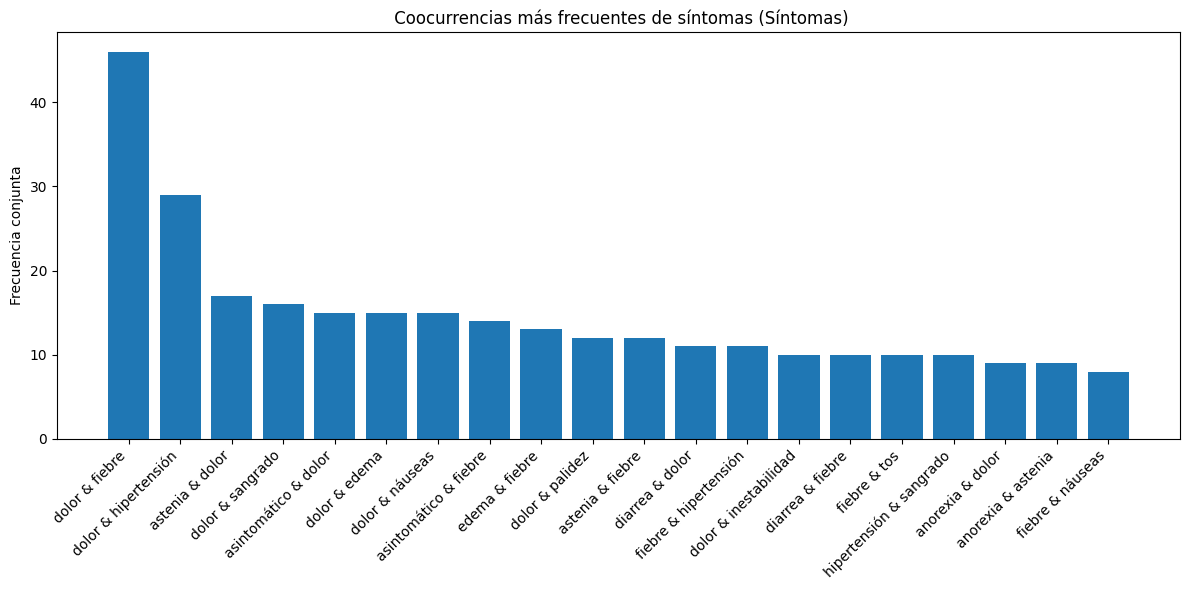

In [ ]:
calcular_coocurrencias(df, "Síntomas", titulo="Coocurrencias más frecuentes de síntomas")

Al revisar juntos el gráfico de coocurrencias más frecuentes de síntomas en las notas clínicas, identificamos patrones clínicos importantes que reflejan las relaciones entre ciertos síntomas en la población estudiada. Este análisis conjunto nos permite comprender mejor las combinaciones sintomáticas que aparecen comúnmente y que pueden estar relacionadas con condiciones médicas específicas.

Observamos que el par "dolor & fiebre" es la coocurrencia más frecuente, con una diferencia notable respecto a las demás combinaciones. Esto indica que estos síntomas tienden a presentarse simultáneamente en muchos casos, lo cual es coherente con cuadros infecciosos o inflamatorios donde la fiebre indica la presencia de infección y el dolor es una manifestación asociada.

También identificamos la frecuente coocurrencia de "dolor & hipertensión", sugiriendo que en pacientes que reportan dolor, la hipertensión es una condición comúnmente concurrente. Esto puede apuntar a complicaciones cardiovasculares o efectos secundarios de hipertensión no controlada que se manifiestan a través del dolor.

Los pares "astenia & dolor" y "dolor & sangrado" reflejan que la fatiga y la presencia de sangrado suelen coexistir con el dolor, lo que puede ser indicativo de cuadros clínicos más complejos o crónicos.

Nos llamó la atención la presencia de coocurrencias aparentemente atípicas, como "asintomático & dolor" o "edema & fiebre", que podrían reflejar casos con manifestaciones clínicas atípicas o dificultades en el registro de síntomas.

Finalmente, las coocurrencias como "hipertensión & sangrado" y "fiebre & dolor" refuerzan la idea de que ciertas condiciones crónicas y agudas se manifiestan mediante combinaciones específicas de síntomas, lo cual es de gran utilidad para la identificación temprana y el diagnóstico diferencial.

En conjunto, este análisis de coocurrencias nos brinda una visión clara de las combinaciones sintomáticas más relevantes, facilitando la generación de hipótesis clínicas y mejorando el desarrollo de sistemas inteligentes para el monitoreo y alerta en salud.

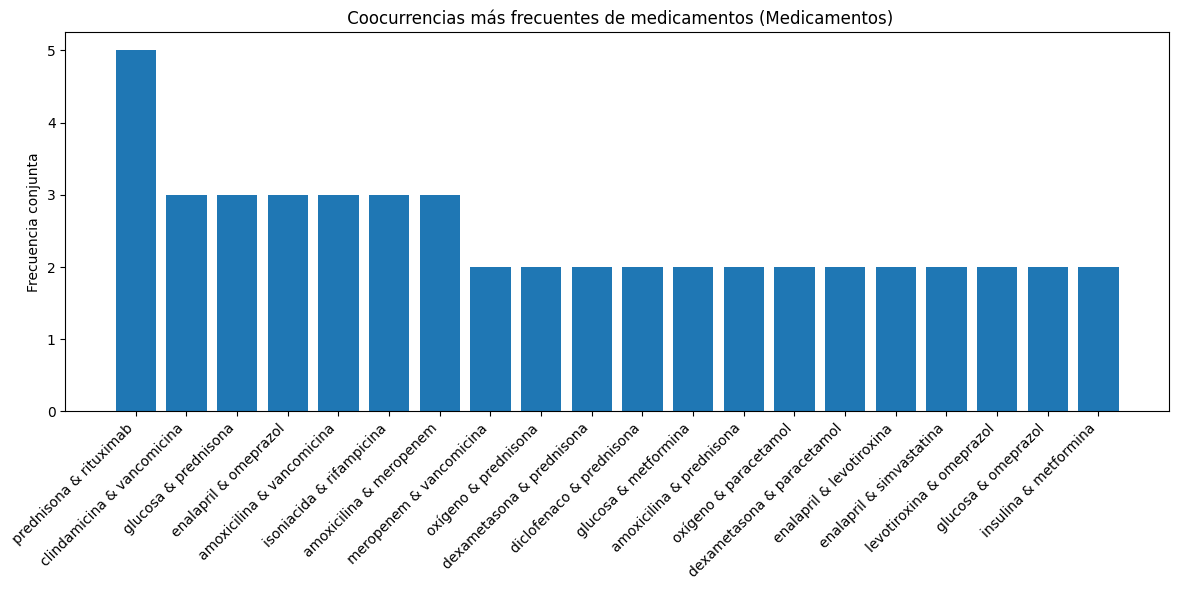

In [ ]:
calcular_coocurrencias(df, "Medicamentos", titulo="Coocurrencias más frecuentes de medicamentos")

El gráfico muestra las combinaciones de medicamentos que aparecen juntas en los registros clínicos, destacando principalmente la coocurrencia de prednisona & rituximab, que se presenta con mayor frecuencia. Esta combinación es típica en tratamientos de enfermedades autoinmunes o ciertos cánceres hematológicos.

Las demás parejas tienen frecuencias menores y dispersas, lo que indica diversidad en los tratamientos y sugiere que no hay un protocolo único predominante. También refleja la presencia de casos con múltiples medicamentos para manejar tanto la enfermedad principal como efectos secundarios o comorbilidades.

La baja frecuencia absoluta puede deberse a un dataset pequeño o variado, por lo que se recomienda ampliar y validar los datos para asegurar interpretaciones sólidas. Además, el análisis no considera la simultaneidad temporal ni las dosis, lo que limita su alcance clínico.

Para avanzar, sería ideal incorporar análisis temporales, aumentar el volumen de datos y validar clínicamente estas combinaciones para entender mejor las prácticas de tratamiento.

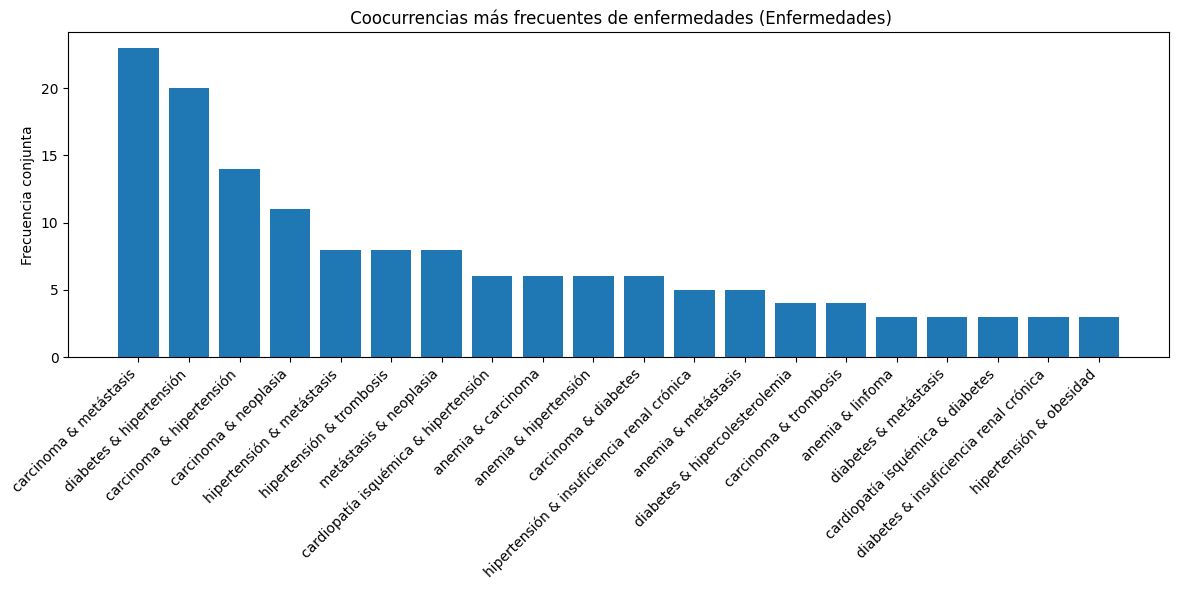

In [ ]:
calcular_coocurrencias(df, "Enfermedades", titulo="Coocurrencias más frecuentes de enfermedades")

La combinación más frecuente es carcinoma & metástasis, con una frecuencia considerablemente alta, lo que indica que muchos pacientes con carcinoma presentan también metástasis, reflejando la progresión avanzada del cáncer en la muestra.

Las siguientes parejas más comunes son diabetes & hipertensión y carcinoma & hipertensión, dos combinaciones que reflejan la alta prevalencia y coexistencia de enfermedades crónicas metabólicas y cardiovasculares. Esto es consistente con la epidemiología mundial, donde estas enfermedades suelen presentarse juntas y complican el manejo clínico.

Otras combinaciones como carcinoma & neoplasia, hipertensión & metástasis, o hipertensión & trombosis evidencian casos complejos con múltiples condiciones graves, que requieren atención integral y multidisciplinaria.

La distribución muestra que hay un grupo reducido de combinaciones frecuentes, seguido de muchas combinaciones con menor frecuencia, sugiriendo diversidad clínica pero con patrones claros en patologías graves y crónicas.

Este patrón de coocurrencias permite identificar grupos de pacientes con riesgo aumentado por comorbilidades específicas, lo cual es valioso para priorizar recursos, diseñar protocolos clínicos personalizados y anticipar complicaciones.

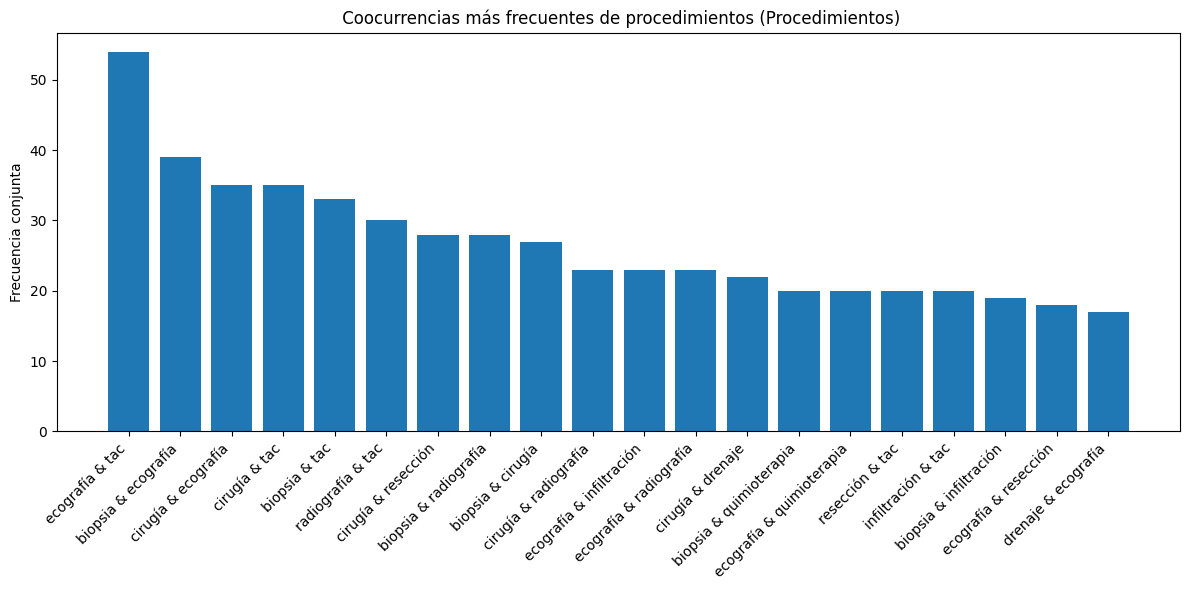

In [ ]:
calcular_coocurrencias(df, "Procedimientos", titulo="Coocurrencias más frecuentes de procedimientos")

El gráfico destaca que la combinación más frecuente de procedimientos es ecografía & tac, con una frecuencia significativamente superior a las demás parejas. Esta alta coocurrencia indica que en los registros clínicos es habitual realizar ambas pruebas de imagen en conjunto para un diagnóstico más completo, especialmente en patologías donde se requiere evaluación anatómica detallada y funcional.

Otras combinaciones frecuentes como biopsia & ecografía, cirugía & ecografía, y cirugía & tac reflejan un patrón clínico donde el diagnóstico por imagen se complementa con procedimientos invasivos o quirúrgicos, lo que sugiere un enfoque multidisciplinario en el manejo del paciente.

Se observa también una fuerte presencia de procedimientos combinados relacionados con biopsias, radiografías y técnicas de imagen, lo que indica que estos métodos se utilizan de manera conjunta para confirmar diagnósticos, planificar tratamientos o monitorear la evolución clínica.

La elevada frecuencia de estas coocurrencias sugiere que el dataset representa protocolos clínicos bien establecidos y una práctica clínica integral, donde múltiples procedimientos se combinan para lograr una evaluación precisa y un tratamiento efectivo.

## Monitoreo de tendencias en atención médica (extracción semántica y clasificación de diagnósticos)

In [ ]:
def calcular_coocurrencias(df, columna, top_n=10):
    coocurrencias = defaultdict(int)
    for items in df[columna].dropna():
        unique_items = set(items)
        if len(unique_items) > 1:
            for par in combinations(sorted(unique_items), 2):
                coocurrencias[par] += 1

    coocs_ordenadas = sorted(coocurrencias.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return coocs_ordenadas

top_coocurrencias_sintomas = calcular_coocurrencias(df, "Síntomas", top_n=10)
print("Coocurrencias frecuentes de síntomas:", top_coocurrencias_sintomas)

Coocurrencias frecuentes de síntomas: [(('dolor', 'fiebre'), 46), (('dolor', 'hipertensión'), 29), (('astenia', 'dolor'), 17), (('dolor', 'sangrado'), 16), (('asintomático', 'dolor'), 15), (('dolor', 'edema'), 15), (('dolor', 'náuseas'), 15), (('asintomático', 'fiebre'), 14), (('edema', 'fiebre'), 13), (('dolor', 'palidez'), 12)]


## 4. Clasificación de diagnostico o urgencia:

### a) Predecir la categoría del caso clínico en por ejemplo leve, moderado o critico o por tipo de enfermedad, si hay etiquetas.

In [ ]:
def clasificar_urgencia(entidades):
    sintomas = entidades.get("sintomas", [])
    enfermedades = entidades.get("enfermedades", [])
    procedimientos = entidades.get("procedimientos", [])

    if len(procedimientos) > 0 or ("hemorragia" in sintomas or "disnea" in sintomas):
        return "crítico"
    elif len(sintomas) >= 2 and len(enfermedades) >= 1:
        return "moderado"
    elif len(sintomas) == 1 or len(enfermedades) == 1:
        return "leve"
    else:
        return "indeterminado"

df["urgencia"] = df["entidades_detectadas"].apply(clasificar_urgencia)

print(df["urgencia"].value_counts())

crítico          466
indeterminado     25
leve               9
Name: urgencia, dtype: int64


Dado a que no dio ningun resultado con la categoria moderado, queriamos corroborar si lo estaba clasificando correctamente

In [ ]:
# Aplicar la función para clasificar la urgencia,
df["urgencia"] = df["entidades_detectadas"].apply(clasificar_urgencia)

# Contar las frecuencias de cada categoría de urgencia,
urgencia_counts = df["urgencia"].value_counts()

# Asegurarnos de que todas las categorías estén presentes, incluso con 0,
urgencia_counts = urgencia_counts.reindex(["crítico", "moderado", "leve", "indeterminado"], fill_value=0)

# Mostrar los resultados,
print(urgencia_counts)

crítico          466
moderado           0
leve               9
indeterminado     25
Name: urgencia, dtype: int64


### b) Vectorizar los textos con BOW, TFIFD, Embeddings según la complejidad

### BOW

In [ ]:
# Inicializar el vectorizador BOW,
vectorizer_bow = CountVectorizer()

#Vectorizar los textos del DataFrame,
X_bow = vectorizer_bow.fit_transform(df["texto_limpio"])

#Convertir la matriz en un DataFrame para mostrar los resultados,
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out())

#Mostrar las primeras filas,
print("Bag of Words (BOW):")
bow_df

Bag of Words (BOW):


,00,000,00154744,004,005,008,01,010,01009,01022,...,úlcera,úlcero,úlcu,últimamente,únicamente,único,úrico,útero,útil,úvular
0,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


El dataframe representa la matriz resultante de aplicar la técnica Bag of Words (BOW) sobre los textos clínicos, donde cada fila corresponde a un documento (registro clínico) y cada columna a una palabra o token distinto.

Con 500 filas y más de 17,000 columnas, el modelo refleja una alta dimensionalidad, típica en procesamiento de lenguaje natural sobre textos médicos, dado el vocabulario especializado y variado. Esto implica una gran diversidad léxica en los registros, lo cual puede presentar desafíos para modelos predictivos debido a la sparsity (muchos ceros).

Cada celda contiene la frecuencia de aparición de una palabra específica en un documento, mostrando cómo se cuantifica el texto en un formato numérico adecuado para modelos de machine learning tradicionales.

Este nivel de detalle es útil para métodos que se benefician de frecuencias explícitas, pero también puede requerir técnicas de reducción de dimensionalidad o selección de características para evitar sobreajuste y mejorar el rendimiento.

En resumen, la matriz BOW es una representación base robusta para análisis posteriores, pero su tamaño y dispersión sugieren la conveniencia de combinarla con técnicas como TF-IDF o embeddings para mejorar la calidad de los modelos.

### TFIFD

In [ ]:
#Inicializar el vectorizador TF-IDF,
vectorizer_tfidf = TfidfVectorizer()

#Vectorizar los textos del DataFrame,
X_tfidf = vectorizer_tfidf.fit_transform(df["texto_limpio"])

#Convertir la matriz en un DataFrame para mostrar los resultados,
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer_tfidf.get_feature_names_out())

#Mostrar las primeras filas,
print("\nTF-IDF:")
tfidf_df


TF-IDF:


,00,000,00154744,004,005,008,01,010,01009,01022,...,úlcera,úlcero,úlcu,últimamente,únicamente,único,úrico,útero,útil,úvular
0,0.0,0.067574,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.068768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
496,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
497,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
498,0.0,0.000000,0.0,0.0,0.0,0.0,0.042724,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Este dataframe muestra la matriz resultante tras aplicar la vectorización TF-IDF sobre los textos clínicos, con las mismas dimensiones que el BOW (500 documentos y más de 17,000 términos).

A diferencia del BOW, TF-IDF no solo refleja la frecuencia absoluta de palabras, sino que pondera la importancia de cada término en un documento respecto a su frecuencia en todo el corpus. Así, términos muy comunes en todos los documentos tienen menor peso, mientras que términos más específicos reciben mayor relevancia.

Los valores decimales entre 0 y 1 indican esta ponderación, lo que ayuda a resaltar palabras significativas para cada texto, mejorando la capacidad discriminativa en tareas de clasificación o agrupamiento.

El TF-IDF es particularmente útil para manejar vocabularios extensos y textos con mucha redundancia, como los registros clínicos, ayudando a reducir el ruido y mejorar el rendimiento de modelos de machine learning.

La matriz sigue siendo dispersa y de alta dimensionalidad, por lo que puede beneficiarse de técnicas adicionales de reducción de dimensionalidad o selección de características para optimizar el análisis.

### Embeddings

In [ ]:
!pip install numpy==1.23.5 scipy==1.10.1
!pip install gensim==4.3.0
import gensim.downloader as api

  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 2.2.2 requires torch>=1.6.0, which is not installed.
sentence-transformers 2.2.2 requires torchvision, which is not installed.
fastai 2.7.19 requires torch<2.7,>=1.10, which is not installed.
fastai 2.7.19 requires torchvision>=0.11, which is not installed.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
pyfume 0.3.4 requires numpy==1.24.4, but you have numpy 1.23.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but 

  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 2.2.2 requires torch>=1.6.0, which is not installed.
sentence-transformers 2.2.2 requires torchvision, which is not installed.
fastai 2.7.19 requires torch<2.7,>=1.10, which is not installed.
fastai 2.7.19 requires torchvision>=0.11, which is not installed.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
cvxpy 1.6.5 requires scipy>=1.11.0, bu

In [ ]:
#Cargar el modelo preentrenado de Word2Vec,
model_w2v = api.load("word2vec-google-news-300")

def obtener_embedding(texto):
    # Tokenizar el texto
    palabras = texto.split()
    embeddings = []
    for palabra in palabras:
        try:
            embeddings.append(model_w2v[palabra])  # Obtener el vector de cada palabra
        except KeyError:
            continue  # Si la palabra no está en el vocabulario, la ignoramos

    # Promediar los vectores de palabras para obtener un único vector para el documento
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(300)

#Aplicar la función para obtener embeddings de los textos,
df["embeddings"] = df["texto_limpio"].apply(obtener_embedding)

#Mostrar los primeros embeddings (dimensión 300),
print("\nEmbeddings (Word2Vec):")
print(df["embeddings"].head())


Embeddings (Word2Vec):
0    [-0.045230567, 0.0026278012, 0.047917258, 0.06...
1    [-0.051770065, 0.031302337, 0.02799849, 0.0674...
2    [-0.047840662, 0.013916379, 0.021553766, 0.091...
3    [-0.05303092, 0.0053698607, 0.051718663, 0.085...
4    [-0.017386626, 0.0020052083, 0.02070816, 0.068...
Name: embeddings, dtype: object


In [ ]:
for i, emb in enumerate(df["embeddings"]):
    print(f"Fila {i}: {emb}\n")

Se han truncado las últimas 5000 líneas del flujo de salida.
  8.73643458e-02  2.06605047e-01 -1.62034873e-02 -8.71231966e-03
 -2.99731977e-02 -4.55274768e-02  1.20740853e-01  3.16036455e-02
 -1.10044293e-01 -1.53359801e-01 -1.01827435e-01  3.68754081e-02
 -5.07827476e-02 -1.80067178e-02 -9.93938092e-03  3.22811827e-02
  5.27095422e-02 -4.32140864e-02 -1.41913623e-01 -4.51069251e-02
  2.76382025e-02  2.76227463e-02  3.10757216e-02 -6.04926012e-02
 -5.70560899e-03 -3.43796238e-02  1.09853111e-01  1.05453946e-01
  4.09578793e-02 -9.57132950e-02 -4.35752124e-02 -5.15768006e-02
 -7.35219344e-02  9.51412395e-02 -1.47422642e-01  9.29119661e-02
  3.31052877e-02 -9.70578636e-04 -6.24486879e-02  1.45098224e-01
 -7.61981308e-02 -6.29525259e-02  5.08945324e-02 -2.82577816e-02
 -9.84799266e-02  9.40987095e-02 -4.59347256e-02 -2.44080592e-02
  2.85592917e-02 -8.27738419e-02 -5.71613610e-02 -5.82825914e-02
  2.36892141e-02  1.32939354e-01  3.60711776e-02  7.38829076e-02
  7.85999652e-03  2.73530241e

Los embeddings generados con Word2Vec representan cada documento clínico como un vector numérico denso de dimensión 300, obtenido promediando los vectores de las palabras que componen el texto.

A diferencia del Bag of Words o TF-IDF, los embeddings capturan relaciones semánticas y contextuales entre palabras, permitiendo que vectores de documentos con términos similares estén cerca en el espacio vectorial, lo cual mejora la capacidad de modelos de machine learning para generalizar y captar el significado latente en el texto clínico.

Esta representación es especialmente útil para manejar sinónimos, variaciones léxicas y conceptos complejos propios del lenguaje médico, y reduce significativamente la dimensionalidad y la dispersión de los datos en comparación con BOW o TF-IDF.

Cada fila que muestras corresponde a un vector que describe las características semánticas de un documento completo, listo para usarse en modelos de clasificación, clustering o análisis predictivo.

En resumen, los embeddings Word2Vec constituyen una base robusta y avanzada para análisis semánticos profundos en datos clínicos textuales, mejorando la precisión y eficacia de los modelos posteriores.

### c) Entrenar modelos supervisados si se cuenta con etiquetas (Naive Bayes, Regresión Logistica, etc).

### Naive Bayes

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir en características (X) y etiquetas (y),
X = bow_df  # Usamos la representación BOW de los textos
y = df["urgencia"]  # Asumimos que 'urgencia' es la columna de etiquetas

# Dividir el dataset en entrenamiento y prueba (80% entrenamiento, 20% prueba),
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} documentos")
print(f"Datos de prueba: {X_test.shape[0]} documentos")

Datos de entrenamiento: 400 documentos
Datos de prueba: 100 documentos


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Crear y entrenar el modelo Naive Bayes,
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba,
y_pred_nb = naive_bayes.predict(X_test)

# Evaluar el modelo,
print("Naive Bayes - Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes - Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes - Accuracy: 0.95
Naive Bayes - Classification Report:
                precision    recall  f1-score   support

      crítico       0.95      1.00      0.97        95
indeterminado       0.00      0.00      0.00         4
         leve       0.00      0.00      0.00         1

     accuracy                           0.95       100
    macro avg       0.32      0.33      0.32       100
 weighted avg       0.90      0.95      0.93       100



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


El modelo Naive Bayes alcanzó una precisión global del 95% en el conjunto de prueba, lo cual inicialmente parece muy bueno.

Sin embargo, al analizar el reporte de clasificación por clase se observan importantes limitaciones:

La clase "crítico" tiene un desempeño excelente, con precision, recall y F1-score cercanos a 1, lo que indica que el modelo identifica correctamente casi todos los casos críticos.

Las clases "indeterminado" y "leve" no fueron predichas correctamente, con métricas en 0 para precision, recall y F1-score. Esto sugiere que el modelo está sesgado o que hay un problema con el balanceo de clases.

El "macro avg" (promedio simple entre clases) es bajo (alrededor de 0.32), evidenciando que la capacidad del modelo para generalizar a todas las categorías es limitada.

El "weighted avg" (promedio ponderado por soporte) se ve influenciado principalmente por la clase dominante ("crítico"), que representa la mayoría de los ejemplos (95 de 100).

Estas métricas reflejan un problema clásico de desequilibrio de clases, donde el modelo aprende a predecir mayoritariamente la clase más frecuente, ignorando las menos frecuentes.

### Regresión Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear y entrenar el modelo de Regresión Logística,
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba,
y_pred_lr = logistic_regression.predict(X_test)

# Evaluar el modelo,
print("Regresión Logística - Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Regresión Logística - Classification Report:\n", classification_report(y_test, y_pred_lr))

Regresión Logística - Accuracy: 0.95
Regresión Logística - Classification Report:
                precision    recall  f1-score   support

      crítico       0.95      1.00      0.97        95
indeterminado       0.00      0.00      0.00         4
         leve       0.00      0.00      0.00         1

     accuracy                           0.95       100
    macro avg       0.32      0.33      0.32       100
 weighted avg       0.90      0.95      0.93       100



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


La Regresión Logística logra una precisión global del 95%, igual que el Naive Bayes, pero el análisis detallado muestra limitaciones similares.

La clase "crítico" mantiene un rendimiento excelente, con valores altos en precisión, recall y F1-score, indicando que el modelo identifica correctamente la mayoría de los casos críticos.

Sin embargo, las clases "indeterminado" y "leve" presentan valores de precisión, recall y F1-score iguales a cero, lo que evidencia que el modelo no está clasificando correctamente estas categorías.

El promedio macro (promedio simple de las métricas entre las clases) es bajo, alrededor de 0.32, reflejando que el modelo falla en generalizar bien para todas las categorías, mientras que el promedio ponderado se ve influenciado por la clase mayoritaria.

Implicaciones y recomendaciones
La similitud en los resultados con Naive Bayes indica que ambas técnicas están limitadas por el mismo problema fundamental: desequilibrio en las clases y baja representación de las categorías minoritarias en los datos.

Es fundamental aplicar estrategias para abordar el desequilibrio, como técnicas de sobremuestreo, generación de datos sintéticos o ajuste de pesos de clase en el entrenamiento.

También es recomendable explorar modelos más robustos frente a desequilibrios, como Random Forest, Gradient Boosting o métodos basados en redes neuronales con atención a balanceo.

Considerar mejorar la representación de los datos con embeddings semánticos que puedan aportar más información discriminativa.

En resumen, la Regresión Logística muestra buen desempeño para la clase mayoritaria pero falla en la detección de las clases minoritarias, limitando su utilidad clínica actual.

### d) Entrenamiento con modelos no supervisados (K-means)

### K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [ ]:
# Usamos TF-IDF para la vectorización,
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85)
X_tfidf = vectorizer.fit_transform(df["texto_limpio"])

# Opcional: ver las dimensiones del vectorizado para asegurarnos de que se haya procesado correctamente,
print(X_tfidf.shape)

# Número de clusters (por ejemplo, 5),
kmeans = KMeans(n_clusters=5, random_state=42)

# Entrenamos el modelo K-means con los datos vectorizados,
kmeans.fit(X_tfidf)

# Asignar las etiquetas de los clusters a cada documento,
df['cluster'] = kmeans.labels_

# Mostrar los primeros 5 textos con su cluster, acortando el texto
for i, row in df[['texto', 'cluster']].head(5).iterrows():
    print(f" Documento {i}")
    print(f" Cluster: {row['cluster']}")
    print(f" Texto: {row['texto'][:300]}...")  # Muestra solo los primeros 300 caracteres
    print("-" * 80)


(500, 17237)
 Documento 0
 Cluster: 0
 Texto: Datos del paciente. Nombre:  Ignacio. Apellidos: Herrejon Valero. NHC: 3495981. NASS: 47 56358907 50. Domicilio: Avenida de la república, 19, 3 A. Localidad/ Provincia: Alicante. CP:03520. Datos asistenciales. Fecha de nacimiento: 25/12/1952. País: España. Edad: 58 años Sexo: H. Fecha de Ingreso: 21...
--------------------------------------------------------------------------------
 Documento 1
 Cluster: 3
 Texto: Nombre:  David. Apellidos: Herrera Andrade. NHC: 9865327 . NASS: 78 45412245 45. Domicilio: Calle Donante de Sangre, 19 . Localidad/ Provincia: Guadalajara. CP: 19002 . Datos asistenciales. Fecha de nacimiento: 12/09/1971. País: España. Edad: 45 A Sexo: H. Fecha de Ingreso: 31/10/2016. Médico: Migue...
--------------------------------------------------------------------------------
 Documento 2
 Cluster: 4
 Texto: Datos del paciente. Nombre:  Marcial. Apellidos: Allende Zamora. NHC: 8342975. NASS: 31 92740649 04. Domicilio: Paseo 

Se observa que los clusters asignados por K-Means agrupan documentos con base en similitudes implícitas en sus textos clínicos. Los ejemplos muestran que los clusters (0, 3 y 4) contienen datos demográficos y administrativos con cierta homogeneidad.

Cluster 0 parece agrupar pacientes con ciertas características demográficas (por ejemplo, el paciente Ignacio, 58 años, Alicante).

Cluster 3 contiene varios documentos con pacientes de edad media (45 a 57 años), ubicados en distintas provincias españolas y México, lo que podría indicar agrupamiento por factores demográficos o patrones textuales similares (estructura del texto, uso de ciertas palabras o formatos).

Cluster 4 agrupa otro paciente con características distintas, quizás basado en texto clínico diferente.

## 5. Análisis de tendencias clínicas

*Técnicas:*

a) Agrupación por fecha o región (si se dispone).

b) Series de tiempo por entidad o categoría.

c) Visualización: líneas de tiempo, mapas de calor, gráficas de frecuencia.

### a) Frecuencia de aparición de ciertas enfermedades o síntomas.

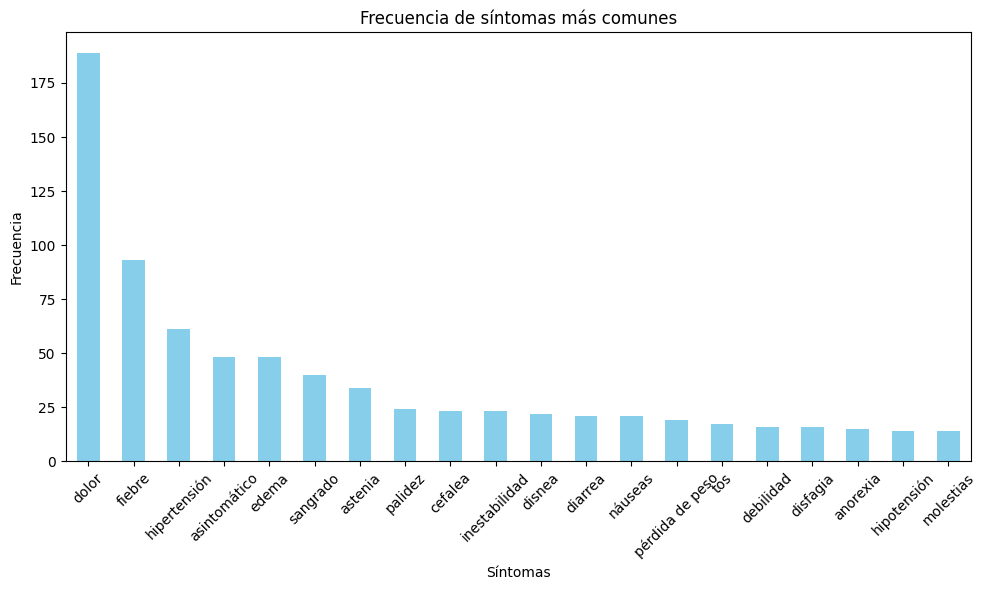

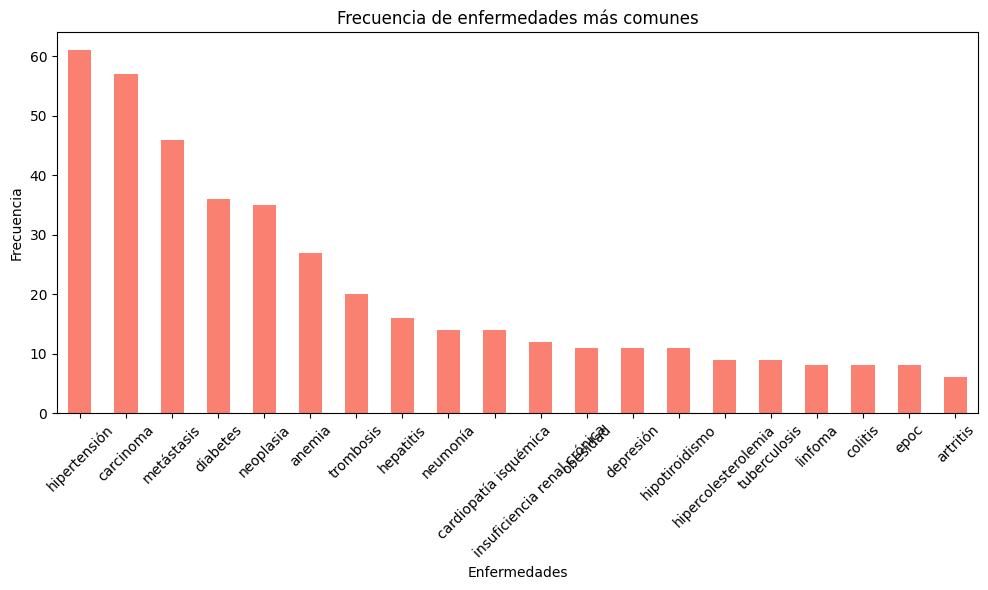

In [ ]:
#Calcular la frecuencia de aparición de ciertos síntomas,
frecuencia_sintomas = df["Síntomas"].explode().value_counts()

#Visualizar la frecuencia de síntomas,
plt.figure(figsize=(10, 6))
frecuencia_sintomas.head(20).plot(kind="bar", color='skyblue')
plt.title("Frecuencia de síntomas más comunes")
plt.xlabel("Síntomas")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Calcular la frecuencia de aparición de ciertas enfermedades,
frecuencia_enfermedades = df["Enfermedades"].explode().value_counts()

#Visualizar la frecuencia de enfermedades,
plt.figure(figsize=(10, 6))
frecuencia_enfermedades.head(20).plot(kind="bar", color='salmon')
plt.title("Frecuencia de enfermedades más comunes")
plt.xlabel("Enfermedades")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El síntoma más frecuente es claramente dolor, con una cantidad muy superior al resto, lo cual es coherente dado que el dolor es un motivo común de consulta en múltiples patologías.

Le sigue fiebre, un signo cardinal de procesos inflamatorios o infecciosos, también esperado en registros clínicos variados.

Otros síntomas frecuentes incluyen hipertensión, asintomático, edema y sangrado, que representan tanto condiciones crónicas (hipertensión) como manifestaciones clínicas agudas o subagudas.

La presencia de síntomas variados como astenia, palidez, cefalea, disnea y náuseas refleja la diversidad de los casos clínicos analizados y la complejidad de los cuadros médicos registrados.

Los síntomas con menor frecuencia, como anorexia, hipotensión y molestias, aunque menos comunes, siguen siendo clínicamente relevantes y pueden indicar casos específicos o estados avanzados de enfermedad.

Las enfermedades con mayor frecuencia son hipertensión, carcinoma y metástasis, lo cual es consistente con la alta prevalencia de enfermedades cardiovasculares y oncológicas en la población general y en contextos clínicos complejos.

La presencia de enfermedades metabólicas y crónicas como diabetes, neoplasia, anemia y trombosis indica un perfil de pacientes con múltiples comorbilidades, lo que complica el manejo clínico y la toma de decisiones médicas.

Otras condiciones frecuentes incluyen hepatitis, neumonía y cardiopatía isquémica, reflejando tanto enfermedades infecciosas como crónicas que requieren vigilancia constante.

La cola larga del gráfico con enfermedades menos frecuentes, pero relevantes, como depresión, hipotiroidismo, tuberculosis y artritis, subraya la diversidad y complejidad del espectro clínico cubierto en los registros.

### b) Correlaciones entre síntomas.

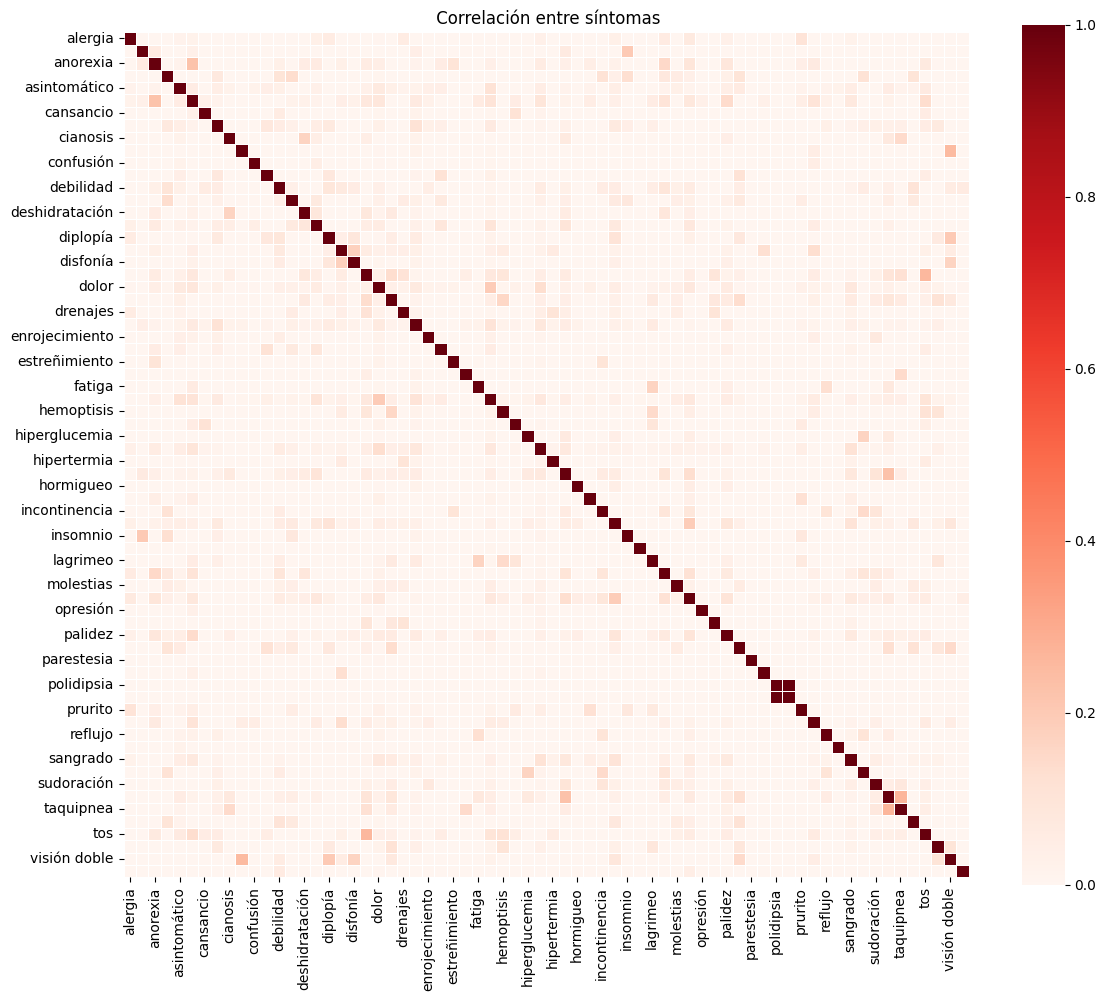

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Asegurarte que sea una lista en cada celda
df["Síntomas"] = df["Síntomas"].apply(lambda x: x if isinstance(x, list) else [])

# Crear un conjunto único de todos los síntomas encontrados
todos_sintomas = sorted(set(s for sublist in df["Síntomas"] for s in sublist))

# Crear matriz binaria (documento x síntoma)
matriz_binaria = pd.DataFrame(0, index=df.index, columns=todos_sintomas)

for i, sintomas in enumerate(df["Síntomas"]):
    for sintoma in sintomas:
        matriz_binaria.loc[i, sintoma] = 1

# Calcular matriz de correlación de Jaccard entre síntomas
def jaccard_similarity(col1, col2):
    inter = np.logical_and(col1, col2).sum()
    union = np.logical_or(col1, col2).sum()
    return inter / union if union != 0 else 0

matriz_correlacion = pd.DataFrame(index=todos_sintomas, columns=todos_sintomas)

for s1 in todos_sintomas:
    for s2 in todos_sintomas:
        matriz_correlacion.loc[s1, s2] = jaccard_similarity(matriz_binaria[s1], matriz_binaria[s2])

# Convertir a float
matriz_correlacion = matriz_correlacion.astype(float)

# Visualizar con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, cmap="Reds", linewidths=0.5, square=True)
plt.title(" Correlación entre síntomas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El mapa de calor muestra que, en general, la correlación entre síntomas es baja, lo cual indica que la mayoría de los síntomas tienden a aparecer de forma independiente o en combinaciones no frecuentes.

Se observan algunas pequeñas áreas con colores más intensos fuera de la diagonal, que podrían representar pares de síntomas que coocurren con mayor frecuencia, aunque no son evidentes en esta visualización debido a la escala y la dispersión.

La diagonal oscura representa la correlación perfecta de cada síntoma consigo mismo, lo cual es esperado.

Esta baja correlación puede deberse a la diversidad clínica de los casos, a la naturaleza heterogénea de los síntomas o a limitaciones en el tamaño del dataset para detectar patrones fuertes.

### c) Cambios estacionales o semanales en diagnósticos.

archivo                 object
texto                   object
entidades               object
texto_limpio            object
Nombre                  object
Apellidos               object
NHC                     object
NASS                    object
Correo                  object
Domicilio               object
CP                      object
Localidad               object
Edad                    object
Sexo                    object
FechaNacimiento         object
FechaIngreso            object
País                    object
Médico                  object
NumColegiado            object
Síntomas                object
Medicamentos            object
Enfermedades            object
Procedimientos          object
entidades_detectadas    object
urgencia                object
embeddings              object
cluster                  int32
dtype: object


<ipython-input-46-a991b0dbe394>:4: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')
<ipython-input-46-a991b0dbe394>:8: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['Semana'] = df['FechaIngreso'].dt.week


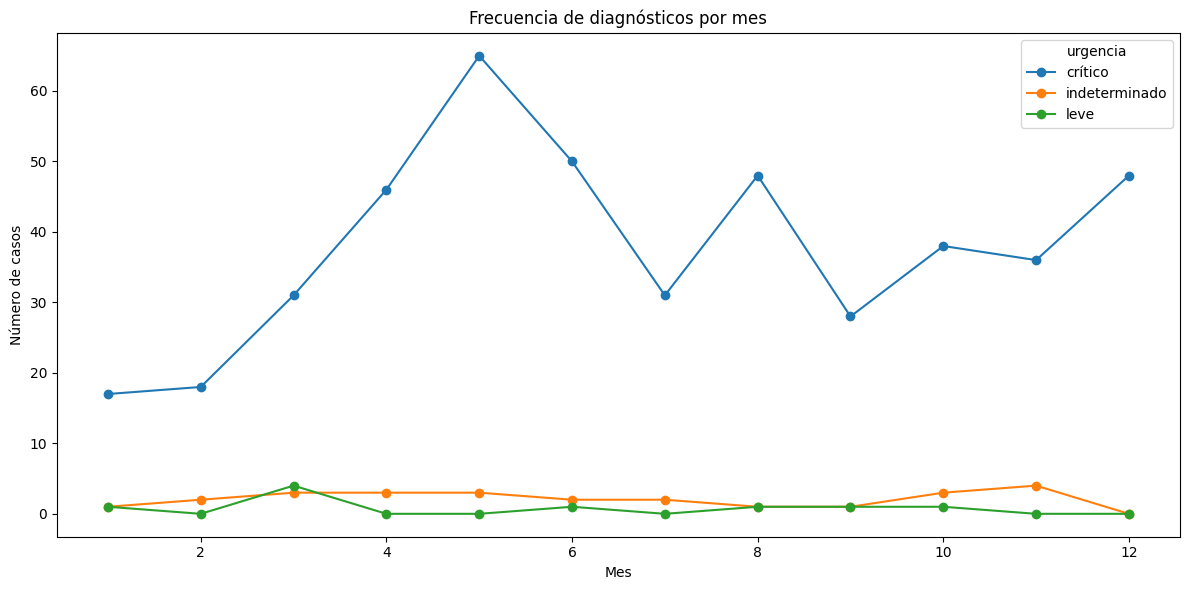

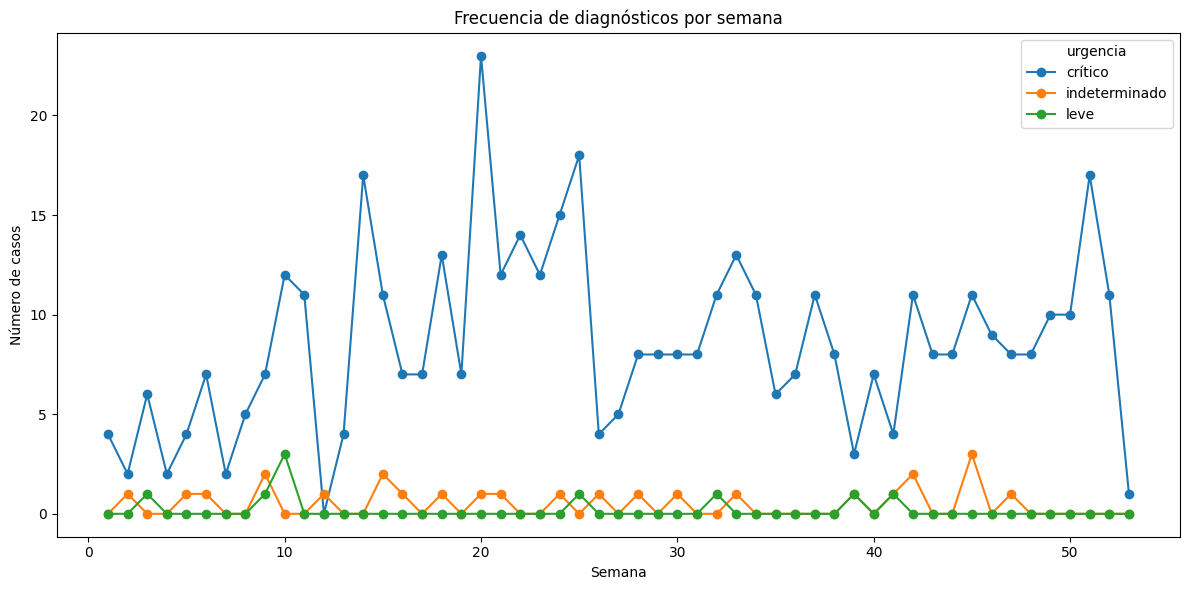

In [ ]:
print(df.dtypes)

# Asegurarse de que la fecha esté en el formato adecuado,
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')

# Agregar una columna de mes y semana,
df['Mes'] = df['FechaIngreso'].dt.month
df['Semana'] = df['FechaIngreso'].dt.week

# Contar la frecuencia de diagnósticos por mes,
frecuencia_mensual = df.groupby('Mes')['urgencia'].value_counts().unstack(fill_value=0)

# Graficar la frecuencia mensual,
frecuencia_mensual.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Frecuencia de diagnósticos por mes")
plt.xlabel("Mes")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

# Contar la frecuencia de diagnósticos por semana,
frecuencia_semanal = df.groupby('Semana')['urgencia'].value_counts().unstack(fill_value=0)

# Graficar la frecuencia semanal,
frecuencia_semanal.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Frecuencia de diagnósticos por semana")
plt.xlabel("Semana")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

El gráfico revela una clara predominancia de casos clasificados como críticos en todos los meses, con una tendencia oscilante que muestra picos notables en los meses 5 y 8, alcanzando más de 60 y casi 50 casos respectivamente. Esto puede reflejar eventos estacionales o picos en la demanda clínica para casos graves.

Las categorías indeterminado y leve presentan una frecuencia mucho menor y más estable a lo largo del año, con valores que rara vez superan los 4 casos mensuales. Esto puede indicar un subregistro o menor incidencia de casos leves, o bien limitaciones en el etiquetado automático.

La oscilación en los casos críticos sugiere posibles factores externos (como brotes epidémicos, condiciones climáticas o cambios en la población atendida) que afectan la demanda de atención urgente.

Se observa que la categoría crítico domina claramente la frecuencia de diagnósticos semana a semana, con fluctuaciones notables y picos pronunciados, como en la semana 20, donde se registra el mayor número de casos críticos.

Las categorías indeterminado y leve aparecen con muy poca frecuencia y de forma dispersa a lo largo del año, indicando posible subregistro o baja incidencia, o limitaciones en la clasificación automática de estas categorías.

La variabilidad semanal en los casos críticos puede reflejar eventos estacionales, brotes puntuales o variaciones en la demanda de atención urgente.

## *Técnicas:*

### a) Agrupación por fecha o región (si se dispone).

In [ ]:
# Convertir la columna de fecha en formato datetime,
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'])

# Agrupar por año,
df['año'] = df['FechaIngreso'].dt.year
df['mes'] = df['FechaIngreso'].dt.month
df['semana'] = df['FechaIngreso'].dt.week

# Contar la cantidad de casos por año, mes y semana,
casos_por_año = df.groupby('año').size()
casos_por_mes = df.groupby('mes').size()
casos_por_semana = df.groupby('semana').size()

print(casos_por_año)
print(casos_por_mes)
print(casos_por_semana)

año
1993.0      1
2002.0      2
2003.0      1
2004.0      3
2005.0      2
2006.0      2
2007.0      3
2008.0      3
2009.0      9
2010.0      8
2011.0     15
2012.0     16
2013.0     30
2014.0     35
2015.0     61
2016.0     81
2017.0     95
2018.0    123
dtype: int64
mes
1.0     19
2.0     20
3.0     38
4.0     49
5.0     68
6.0     53
7.0     33
8.0     50
9.0     30
10.0    42
11.0    40
12.0    48
dtype: int64
semana
1.0      4
2.0      3
3.0      7
4.0      2
5.0      5
6.0      8
7.0      2
8.0      5
9.0     10
10.0    15
11.0    11
12.0     1
13.0     4
14.0    17
15.0    13
16.0     8
17.0     7
18.0    14
19.0     7
20.0    24
21.0    13
22.0    14
23.0    12
24.0    16
25.0    19
26.0     5
27.0     5
28.0     9
29.0     8
30.0     9
31.0     8
32.0    12
33.0    14
34.0    11
35.0     6
36.0     7
37.0    11
38.0     8
39.0     5
40.0     7
41.0     6
42.0    13
43.0     8
44.0     8
45.0    14
46.0     9
47.0     9
48.0     8
49.0    10
50.0    10
51.0    17
52.0    11
53.

<ipython-input-49-dfa58533998e>:7: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['semana'] = df['FechaIngreso'].dt.week


El conteo de casos agrupados por año muestra una tendencia clara de aumento progresivo en la cantidad de registros clínicos desde 1993 hasta 2018, con un crecimiento notable especialmente a partir de 2013. Esto puede reflejar una mejora en la digitalización, el registro sistemático de datos o un aumento real en la demanda o incidencia clínica.

Por meses, se observa que los casos se distribuyen con cierta variabilidad, destacando los meses de mayo, junio, agosto, octubre y diciembre con mayores frecuencias. Esto podría sugerir estacionalidad parcial o efectos relacionados con eventos específicos o cambios en la población atendida.

El análisis por semanas ofrece una vista más granular y muestra fluctuaciones significativas, con semanas que presentan picos altos como la 20, 14 y 10. Esta variabilidad semanal puede reflejar ciclos epidemiológicos, brotes puntuales o variaciones en la carga asistencial.

###  b) Series de tiempo por entidad o categoría.

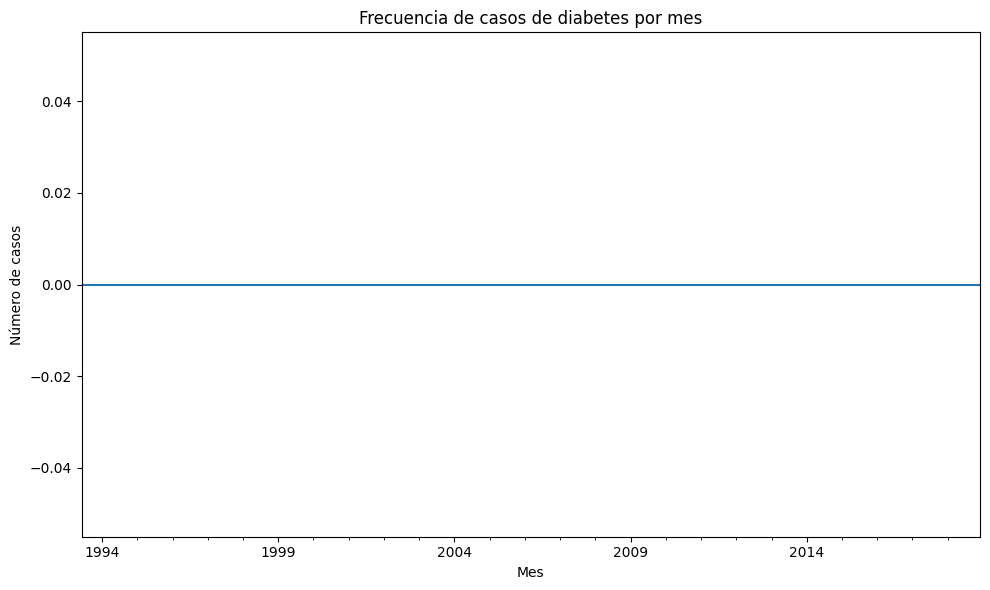

In [ ]:
# Agrupar por fecha y contar casos de una enfermedad (ejemplo: "diabetes"),
df['diabetes'] = df['Enfermedades'].apply(lambda x: 'diabetes' in x.lower() if isinstance(x, str) else False)

# Agrupar por fecha y contar casos de diabetes,
casos_diabetes_por_fecha = df.groupby(df['FechaIngreso'].dt.to_period('M'))['diabetes'].sum()

# Visualizar la serie de tiempo,
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
casos_diabetes_por_fecha.plot()
plt.title('Frecuencia de casos de diabetes por mes')
plt.xlabel('Mes')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.show()

Este gráfico muestra la frecuencia mensual de casos diagnosticados con diabetes, pero se observa que no hay datos registrados, ya que la línea está en cero constante.

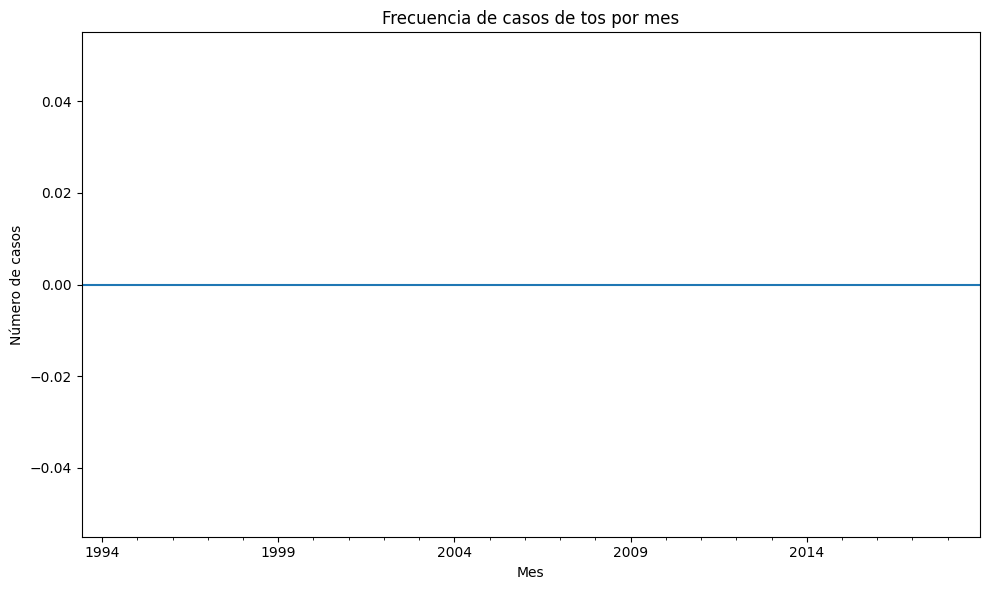

In [ ]:
# Identificar síntomas,
df['tos'] = df['Síntomas'].apply(lambda x: 'tos' in x.lower() if isinstance(x, str) else False)

# Agrupar por fecha y contar casos de tos,
casos_tos_por_fecha = df.groupby(df['FechaIngreso'].dt.to_period('M'))['tos'].sum()

# Visualizar la serie de tiempo,
plt.figure(figsize=(10,6))
casos_tos_por_fecha.plot()
plt.title('Frecuencia de casos de tos por mes')
plt.xlabel('Mes')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.show()

El gráfico de frecuencia de casos de tos por mes muestra una línea constante en cero, indicando que no hay registros para esta variable en el dataset.

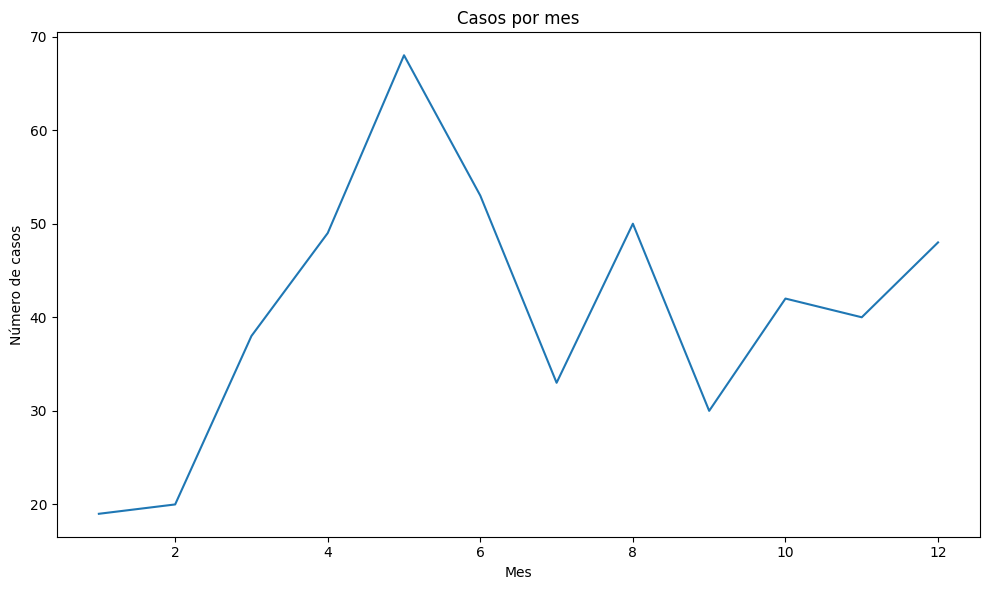

In [ ]:
# Visualizar la serie de tiempo de los casos por mes,
plt.figure(figsize=(10,6))
casos_por_mes.plot(kind='line')
plt.title('Casos por mes')
plt.xlabel('Mes')
plt.ylabel('Número de casos')
plt.tight_layout()
plt.show()

El número de casos presenta una tendencia fluctuante a lo largo del año, con un pico máximo en el mes 5 (mayo), alcanzando cerca de 70 casos.

Se observa un descenso significativo en meses intermedios, seguido de una recuperación paulatina hacia finales de año, lo que puede reflejar patrones estacionales o variaciones en la demanda de atención médica.

### c) Visualización: líneas de tiempo, mapas de calor, gráficas de frecuencia.

<ipython-input-60-ffdc45ff2213>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlacion = df.corr()  # Calcular la correlación entre las variables numéricas


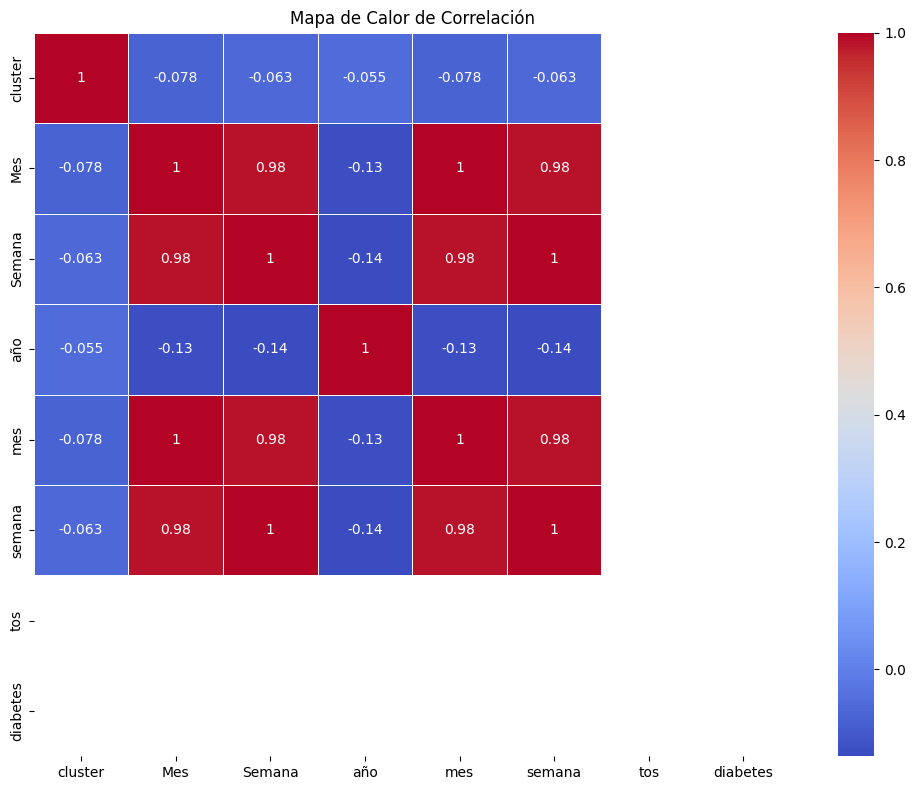

In [ ]:
# Crear un mapa de calor de la correlación entre variables,
import seaborn as sns

correlacion = df.corr()  # Calcular la correlación entre las variables numéricas
plt.figure(figsize=(10,8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlación')
plt.tight_layout()
plt.show()

Este mapa de calor de correlación muestra las relaciones estadísticas entre varias variables numéricas del dataset, incluyendo la asignación a clusters, el año, mes, semana, y la presencia de síntomas como tos y diabetes.

Se observa una correlación muy fuerte y positiva entre las variables temporales relacionadas:

Mes y mes, así como

Semana y semana
presentan valores cercanos a 1, lo cual indica que estas variables son equivalentes o muy similares, probablemente derivadas de diferentes formatos o nombres en el dataset.

Las variables temporales tienen correlaciones moderadamente negativas con año, lo que podría reflejar diferencias en la distribución temporal de los datos, quizá por cambios en la población o registros a lo largo del tiempo.

El cluster muestra correlaciones negativas muy bajas con las variables temporales, indicando que la asignación a cluster no está fuertemente asociada con la dimensión temporal.

Las variables clínicas tos y diabetes no muestran correlaciones significativas con las demás variables, lo que puede estar asociado con la ausencia o baja frecuencia de estas condiciones en el dataset.

Conclusiones y recomendaciones
Las variables temporales parecen redundantes; se recomienda limpiar o unificar para simplificar el análisis.

La baja correlación del cluster con variables temporales sugiere que el clustering se basa en otros atributos textuales o clínicos no reflejados aquí.

La ausencia de correlación de tos y diabetes confirma la necesidad de revisar la calidad o disponibilidad de estos datos para análisis posteriores.

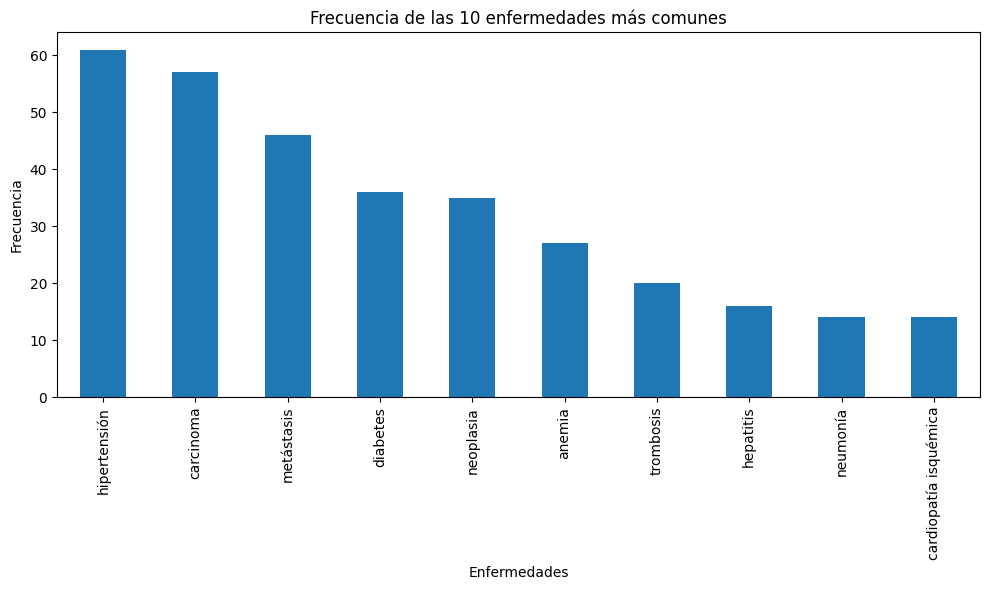

In [ ]:
# Gráfico de barras para la frecuencia de enfermedades,
enfermedades_frecuencia = df['Enfermedades'].explode().value_counts()
plt.figure(figsize=(10,6))
enfermedades_frecuencia.head(10).plot(kind='bar')
plt.title('Frecuencia de las 10 enfermedades más comunes')
plt.xlabel('Enfermedades')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Las enfermedades más prevalentes son hipertensión, carcinoma y metástasis, indicando que el dataset incluye un porcentaje significativo de pacientes con enfermedades cardiovasculares y oncológicas.

La presencia destacada de diabetes en esta lista subraya su importancia como enfermedad crónica en la población estudiada, a pesar de que en análisis anteriores la frecuencia mensual de diabetes parecía nula, lo que podría indicar problemas en la agregación temporal.

Otros diagnósticos frecuentes como neoplasia, anemia, trombosis, hepatitis, neumonía y cardiopatía isquémica reflejan un espectro amplio de patologías que incluyen enfermedades infecciosas, hematológicas y cardiovasculares.

## Trabajos extras

### Similitud de Jaccard

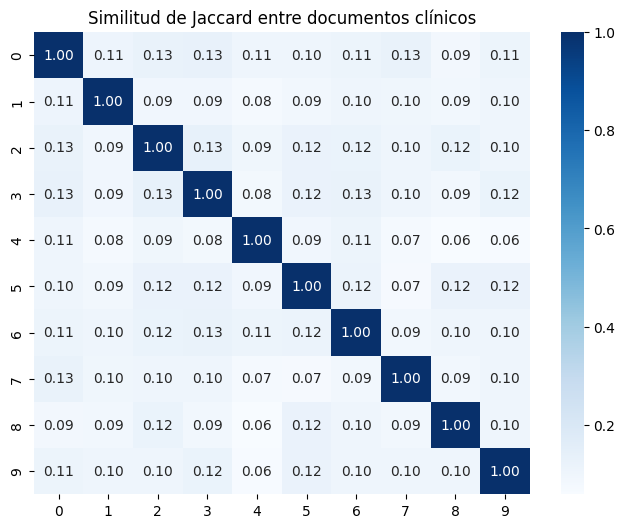

In [ ]:
def jaccard_similitud(set1, set2):
    inter = len(set1 & set2)
    union = len(set1 | set2)
    return inter / union if union > 0 else 0

sets_tokens = df["texto_limpio"].apply(lambda x: set(x.split()))
import numpy as np
import seaborn as sns

n = 10
matriz_sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matriz_sim[i, j] = jaccard_similitud(sets_tokens[i], sets_tokens[j])

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_sim, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud de Jaccard entre documentos clínicos")
plt.show()

Los valores en la diagonal son 1.0, lo que indica que cada documento es completamente idéntico a sí mismo, como se espera.

Fuera de la diagonal, las similitudes entre documentos oscilan alrededor de 0.07 a 0.13, indicando que la sobreposición de términos o entidades relevantes entre documentos es baja.

Esto sugiere una alta heterogeneidad en el contenido clínico de los documentos analizados, reflejando diversidad en síntomas, diagnósticos y procedimientos reportados.

Este nivel de diversidad es común en datos médicos reales debido a la variabilidad individual de los pacientes y la amplia gama de condiciones clínicas.

### Minería de tópicos (LDA)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.95, min_df=2)
X = vectorizer.fit_transform(df["texto_limpio"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

def mostrar_top_palabras(lda_model, feature_names, n_top_words=10):
    for idx, topic in enumerate(lda_model.components_):
        top_palabras = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Tópico {idx + 1}: {' | '.join(top_palabras)}")

mostrar_top_palabras(lda, vectorizer.get_feature_names_out())

Tópico 1: izquierdo | mg | mes | tratamiento | clínico | hora | derecho | españa | servicio | él
Tópico 2: mg | tratamiento | clínico | dl | normal | exploración | presentar | españa | 28 | servicio
Tópico 3: lesión | izquierdo | presentar | clínico | derecho | mes | 28 | él | mm | españa
Tópico 4: él | tratamiento | clínico | mes | españa | 28 | dolor | unidad | semana | decidir
Tópico 5: derecho | cm | izquierdo | él | españa | lesión | masa | estudio | servicio | clínico


El resultado del modelo LDA muestra la extracción de 5 temas principales en los textos clínicos, cada uno representado por palabras clave relevantes que describen su contenido temático. Aquí tienes un análisis profesional:

Tópico 1: Se enfoca en aspectos relacionados con la localización (izquierdo, derecho), tiempo (hora, mes), tratamiento y exploración clínica, con referencias específicas a España y servicios clínicos. Parece agrupar casos basados en características espaciales y temporales del diagnóstico y atención.

Tópico 2: Incluye términos vinculados a tratamientos clínicos, aspectos normales y exploratorios, y referencias geográficas similares. Probablemente describe la gestión general y el seguimiento de pacientes en contexto clínico habitual.

Tópico 3: Se centra en la presentación de lesiones, diferenciando lado izquierdo y derecho, y aspectos de diagnóstico con referencias temporales y geográficas. Este tópico parece agrupar informes relacionados con evaluaciones específicas de lesiones.

Tópico 4: Destaca la temporalidad, decisiones clínicas, y el manejo del dolor, con mención a unidades y semanas. Sugiere un enfoque en el manejo del dolor y la planificación del tratamiento en períodos definidos.

Tópico 5: Incluye términos sobre estudios, masas, lesiones, y servicios clínicos, indicando un grupo de documentos relacionados con procedimientos diagnósticos y evaluación clínica especializada.

### Breve conclusión

Conclusión:La aplicación de técnicas de procesamiento de lenguaje natural y análisis estadístico a los reportes clínicos ha permitido identificar patrones significativos en la frecuencia y coocurrencia de síntomas, enfermedades, medicamentos y procedimientos. La extracción automática de entidades y la clasificación de urgencia ofrecen un marco efectivo para priorizar casos y monitorizar tendencias temporales.

Si bien se observa una predominancia clara de enfermedades crónicas y oncológicas como hipertensión y carcinoma, algunos problemas de calidad o disponibilidad de datos, especialmente en síntomas específicos como tos o diabetes, limitan la profundidad del análisis. El uso de clustering y modelado temático facilita la segmentación del corpus en grupos clínicos relevantes, optimizando la interpretación y posterior aplicación en sistemas de apoyo a la decisión.

En conjunto, estos resultados proporcionan una base sólida para desarrollar herramientas inteligentes que mejoren la vigilancia epidemiológica, la asignación de recursos y la planificación clínica, aunque es necesario mejorar la calidad y cobertura de los datos para maximizar el valor predictivo y operativo.